In [2]:
# Importation des modules et du dataset

In [73]:
# Manipulation des données
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import pointbiserialr, ttest_ind, skew, kruskal

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
from statannot import add_stat_annotation
from skimpy import skim

# Prétraitement des données et évaluation des modèles
from sklearn.decomposition import PCA
from sklearn.preprocessing import (
    MinMaxScaler,
    MaxAbsScaler,
    StandardScaler,
    RobustScaler,
    Normalizer,
    QuantileTransformer,
    PowerTransformer,
    Binarizer
)
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import (
    GaussianNB,
    BernoulliNB,
    MultinomialNB
)
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Traitement des déséquilibres des classes
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Classificateurs avancés
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Autres
import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning
from collections import Counter

# Ignorer les avertissements de convergence
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [4]:
data = pd.read_csv('https://raw.githubusercontent.com/MaskiVal/DataSets/main/diabetes.csv')

# Analyse exploratoire, traitements, modélisation des données

## 1 - Exploration des données

#### 1.1.1 - Nombre de données, visualisation des colonnes du dataset

In [5]:
skim(data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 768    │ │ int32       │ 7     │                                                          │
│ │ Number of columns │ 9      │ │ float64     │ 2     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column_name            ┃ NA  ┃ NA %  ┃ mean    ┃ sd     ┃ p0    ┃ p25    ┃ p50    ┃ p75    ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ Pregnancies            │   0 │     0 │   3.845 │   3.37 │     0 │      1 │      3 │      6 │   17 │  ▇▅▃▁  │  │
│ │ Glucose                │   0 │     0 │   120.9 │  31.97 │     0 │     99 │    117 │  140.2 │  199 │   ▅▇▃▂ │  │
│ │ BloodPressure          │   0 │     0 │   69.11 │  19.36 │     0 │     62 │     72 │     80 │  122 │ ▁ ▂▇▃  │  │
│ │ SkinThickness          │   0 │     0 │   20.54 │  15.95 │     0 │      0 │     23 │     32 │   99 │  ▇▇▅   │  │
│ │ Insulin                │   0 │     0 │    79.8 │  115.2 │     0 │      0 │   30.5 │  127.2 │  846 │   ▇▂   │  │
│ │ BMI                    │   0 │     0 │   31.99 │  7.884 │     0 │   27.3 │     32 │   36.6 │ 67.1 │  ▁▇▆▁  │  │
│ │ DiabetesPedigreeFuncti │   0 │     0 │  0.4719 │ 0.3313 │ 0.078 │ 0.2437 │ 0.3725 │ 0.6262 │ 2.42 │  ▇▃▁   │  │
│ │ on                     │     │       │         │        │       │        │        │        │      │        │  │
│ │ Age                    │   0 │     0 │   33.24 │  11.76 │    21 │     24 │     29 │     41 │   81 │  ▇▃▂▁  │  │
│ │ Outcome                │   0 │     0 │   0.349 │  0.477 │     0 │      0 │      0 │      1 │    1 │ ▇    ▅ │  │
│ └────────────────────────┴─────┴───────┴─────────┴────────┴───────┴────────┴────────┴────────┴──────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [6]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

#### 1.1.2 - Observation des types de données

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### 1.1.3 - Observation des valeurs Null

In [8]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
data[data.duplicated(keep=False)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


### 1.2 - Observation des variables numériques

In [10]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
zero_counts = data.apply(lambda col: (col == 0).sum())
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [12]:
rows_with_zeros = data[(data == 0).any(axis=1)]

pd.DataFrame(rows_with_zeros)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [13]:
data_outcome_0 = data[data['Outcome'] == 0]
data_outcome_1 = data[data['Outcome'] == 1]

In [14]:
zero_counts_outcome_0 = data_outcome_0.apply(lambda col: (col == 0).sum())
print(zero_counts_outcome_0)

Pregnancies                  73
Glucose                       3
BloodPressure                19
SkinThickness               139
Insulin                     236
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [15]:
# Vérification si une ligne a plusieurs zéros
has_multiple_zeros = (data_outcome_0 == 0).sum(axis=1) > 4

# Affichage des lignes qui ont plusieurs zéros
rows_with_multiple_zeros = data_outcome_0[has_multiple_zeros]

data_row_zero_out_0 = pd.DataFrame(rows_with_multiple_zeros)
data_row_zero_out_0

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
336,0,117,0,0,0,33.8,0.932,44,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
589,0,73,0,0,0,21.1,0.342,25,0
697,0,99,0,0,0,25.0,0.253,22,0


In [16]:
zero_counts_outcome_1 = data_outcome_1.apply(lambda col: (col == 0).sum())
print(zero_counts_outcome_1)

Pregnancies                  38
Glucose                       2
BloodPressure                16
SkinThickness                88
Insulin                     138
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [17]:
# Vérification si une ligne a plusieurs zéros
has_multiple_zeros = (data_outcome_1 == 0).sum(axis=1) > 3

# Affichage des lignes qui ont plusieurs zéros
rows_with_multiple_zeros = data_outcome_1[has_multiple_zeros]

data_row_zero_out_1 = pd.DataFrame(rows_with_multiple_zeros)
data_row_zero_out_1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
78,0,131,0,0,0,43.2,0.270,26,1
266,0,138,0,0,0,36.3,0.933,25,1
300,0,167,0,0,0,32.3,0.839,30,1
435,0,141,0,0,0,42.4,0.205,29,1
484,0,145,0,0,0,44.2,0.630,31,1
619,0,119,0,0,0,32.4,0.141,24,1
706,10,115,0,0,0,0.0,0.261,30,1


#### 1.2.1 - Analyse de la distribution

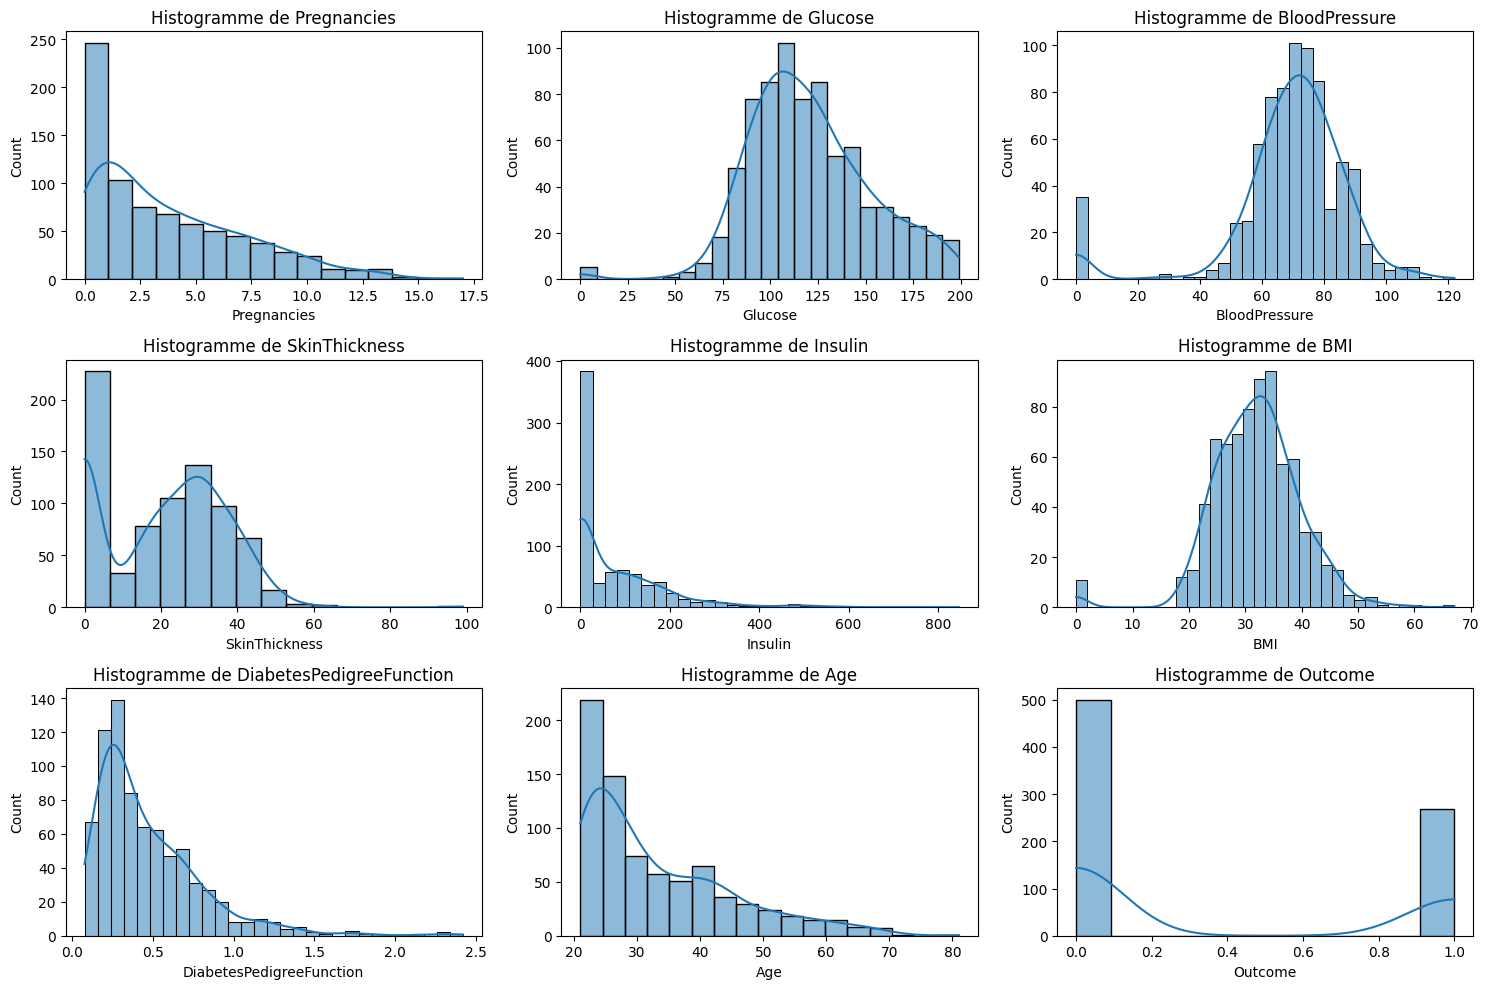

In [18]:
# Créer une figure et des sous-graphiques
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))

# Aplatir la liste des axes pour itérer plus facilement
axs = axs.flatten()

# Parcourir chaque colonne et tracer l'histogramme correspondant
for i, col in enumerate(data.columns):
    sns.histplot(data[col], kde=True, ax=axs[i])
    axs[i].set_title(f'Histogramme de {col}')

# Ajuster les espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

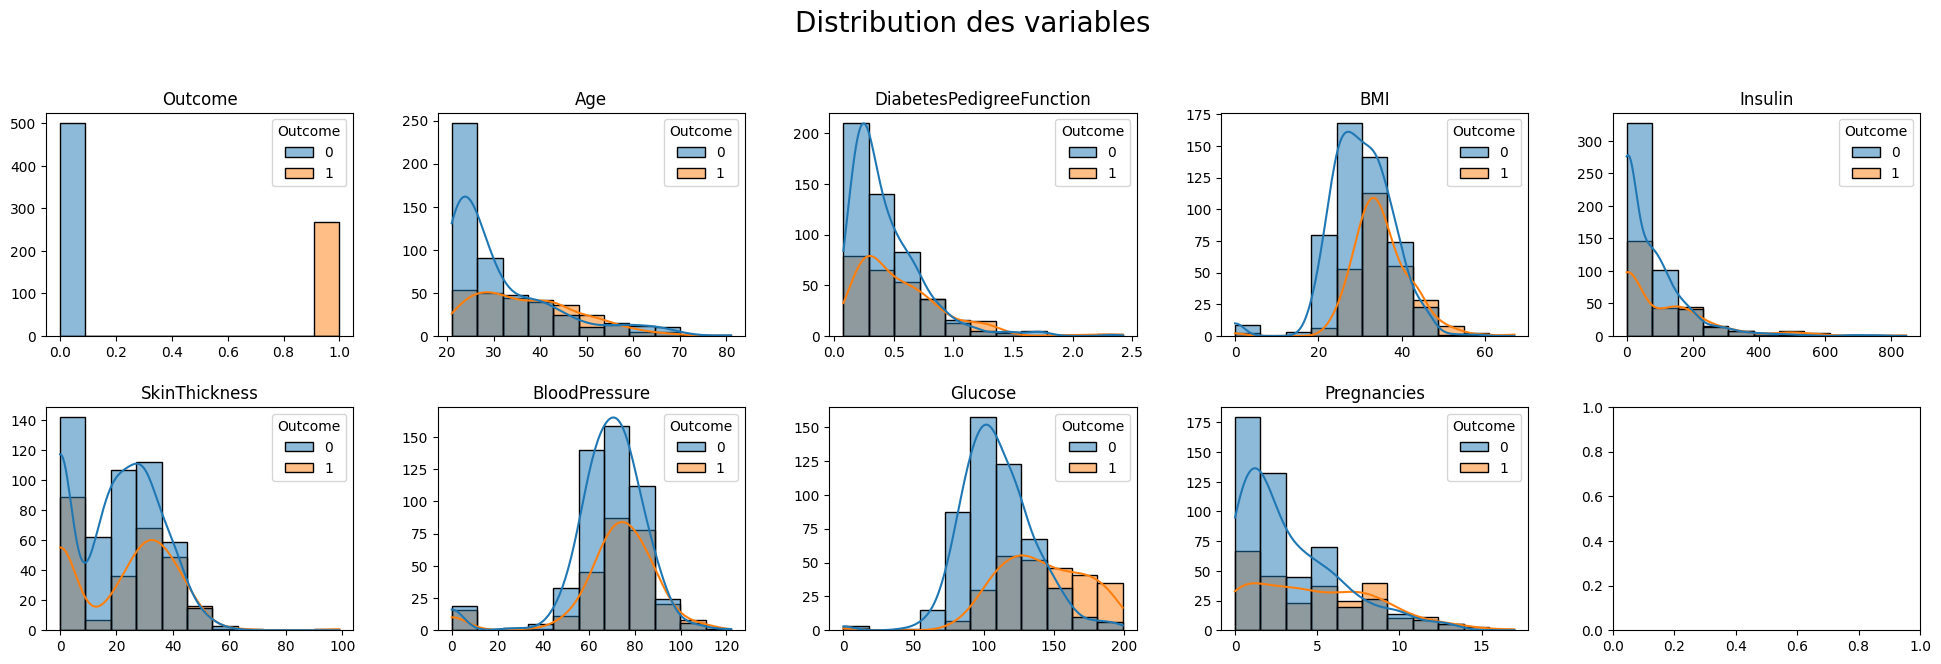

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Distribution des variables', fontsize=20)
fig.tight_layout(pad=3.0)

for i, col in enumerate(data.columns[::-1]):
    sns.histplot(data, x=col, hue='Outcome', bins='sturges', kde=True, ax=axes[i//5, i%5])
    axes[i//5, i%5].set_title(col)
    axes[i//5, i%5].set_xlabel('')
    axes[i//5, i%5].set_ylabel('')
    
plt.show()

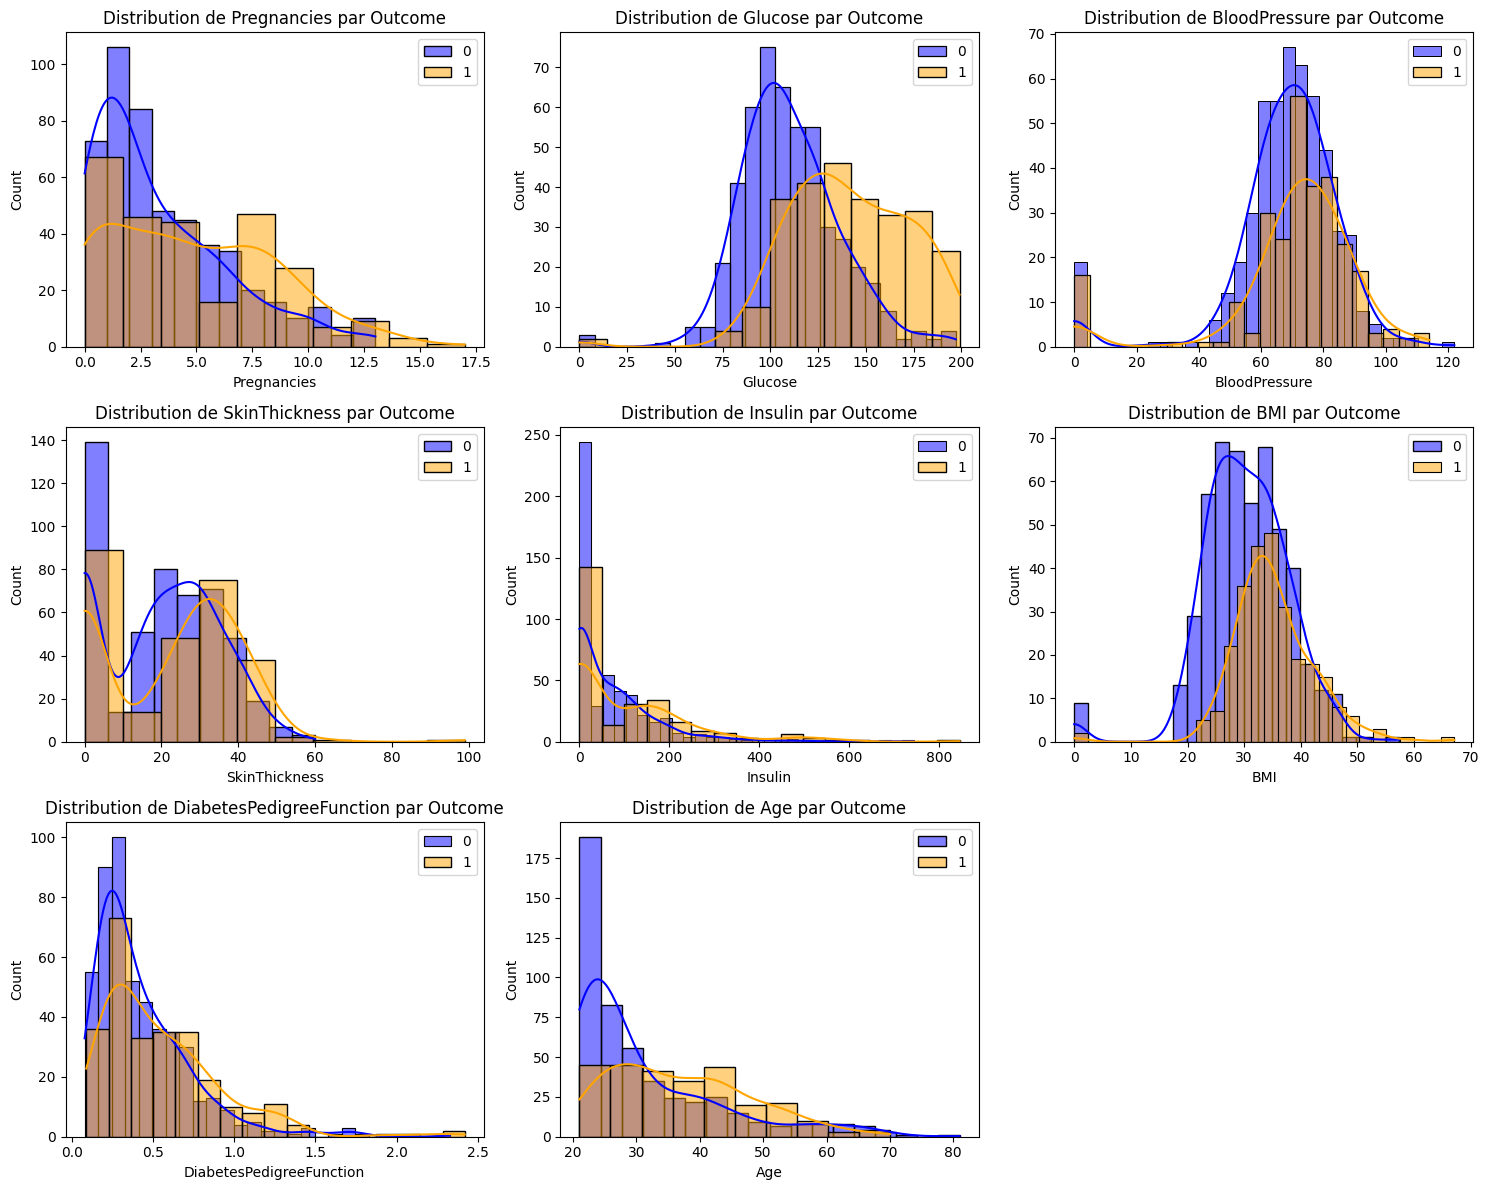

In [20]:
# Liste des caractéristiques à tracer
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

# Créer des sous-graphiques
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Aplatir la liste des axes pour itérer plus facilement
axs = axs.flatten()

# Parcourir chaque caractéristique et tracer les distributions
for i, feature in enumerate(features):
    sns.histplot(data[data['Outcome'] == 0][feature], color='blue', kde=True, ax=axs[i], label='0')
    sns.histplot(data[data['Outcome'] == 1][feature], color='orange', kde=True, ax=axs[i], label='1')
    '''plt.axvline(x=data[data['Outcome'] == 0][feature].median(), color='blue', linestyle='--', label='Mean for 0')
    plt.axvline(x=data[data['Outcome'] == 1][feature].median(), color='orange', linestyle='--', label='Mean for 1')'''
    axs[i].set_title(f'Distribution de {feature} par Outcome')
    axs[i].legend()

# Masquer les sous-graphiques inutilisés
for j in range(i+1, len(axs)):
    axs[j].axis('off')

# Ajuster les espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

In [21]:
# Calculer la skewness pour chaque colonne pour Outcome = 1
skewness_outcome_1 = data_outcome_1.apply(lambda x: skew(x.dropna()))

# Calculer la skewness pour chaque colonne pour Outcome = 0
skewness_outcome_0 = data_outcome_0.apply(lambda x: skew(x.dropna()))

# Afficher les résultats
print("Skewness pour Outcome = 1 :")
print(skewness_outcome_1)

print("\nSkewness pour Outcome = 0 :")
print(skewness_outcome_0)

Skewness pour Outcome = 1 :
Pregnancies                 0.500925
Glucose                    -0.492779
BloodPressure              -1.932738
SkinThickness               0.115260
Insulin                     1.833495
BMI                         0.000593
DiabetesPedigreeFunction    1.712718
Age                         0.578385
Outcome                          NaN
dtype: float64

Skewness pour Outcome = 0 :
Pregnancies                 1.110760
Glucose                     0.172591
BloodPressure              -1.804391
SkinThickness               0.031062
Insulin                     2.491239
BMI                        -0.663903
DiabetesPedigreeFunction    2.000218
Age                         1.566891
Outcome                          NaN
dtype: float64


C:\Users\corre\AppData\Local\Temp\ipykernel_26512\81388528.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness_outcome_1 = data_outcome_1.apply(lambda x: skew(x.dropna()))


In [22]:
'''     Interprétation des résultats :

        Skewness pour Outcome = 1 :
        Pregnancies : Skewness de 0.500925, indiquant une légère asymétrie positive.
        Glucose : Skewness de -0.492779, indiquant une légère asymétrie négative.
        BloodPressure : Skewness de -1.932738, indiquant une asymétrie négative plus prononcée.
        SkinThickness : Skewness de 0.115260, indiquant une légère asymétrie positive.
        Insulin : Skewness de 1.833495, indiquant une forte asymétrie positive.
        BMI : Skewness de 0.000593, indiquant une quasi-symétrie (très proche de zéro).
        DiabetesPedigreeFunction : Skewness de 1.712718, indiquant une forte asymétrie positive.
        Age : Skewness de 0.578385, indiquant une asymétrie positive modérée.
       
        Skewness pour Outcome = 0 :
        Pregnancies : Skewness de 1.110760, indiquant une asymétrie positive.
        Glucose : Skewness de 0.172591, indiquant une légère asymétrie positive.
        BloodPressure : Skewness de -1.804391, indiquant une asymétrie négative assez prononcée.
        SkinThickness : Skewness de 0.031062, indiquant une légère asymétrie positive.
        Insulin : Skewness de 2.491239, indiquant une forte asymétrie positive.
        BMI : Skewness de -0.663903, indiquant une asymétrie négative.
        DiabetesPedigreeFunction : Skewness de 2.000218, indiquant une forte asymétrie positive.
        Age : Skewness de 1.566891, indiquant une asymétrie positive.

        Conclusion :
        
        Les variables telles que Insulin, DiabetesPedigreeFunction et BloodPressure montrent une forte asymétrie positive dans les deux groupes.
        BMI semble être la variable la plus symétrique, avec une skewness proche de zéro dans les deux groupes.
        Les variables comme Glucose, Age et Pregnancies montrent une asymétrie positive modérée à légère.
        BloodPressure montre une asymétrie négative assez prononcée dans les deux groupes.
'''


'     Interprétation des résultats :\n\n        Skewness pour Outcome = 1 :\n        Pregnancies : Skewness de 0.500925, indiquant une légère asymétrie positive.\n        Glucose : Skewness de -0.492779, indiquant une légère asymétrie négative.\n        BloodPressure : Skewness de -1.932738, indiquant une asymétrie négative plus prononcée.\n        SkinThickness : Skewness de 0.115260, indiquant une légère asymétrie positive.\n        Insulin : Skewness de 1.833495, indiquant une forte asymétrie positive.\n        BMI : Skewness de 0.000593, indiquant une quasi-symétrie (très proche de zéro).\n        DiabetesPedigreeFunction : Skewness de 1.712718, indiquant une forte asymétrie positive.\n        Age : Skewness de 0.578385, indiquant une asymétrie positive modérée.\n       \n        Skewness pour Outcome = 0 :\n        Pregnancies : Skewness de 1.110760, indiquant une asymétrie positive.\n        Glucose : Skewness de 0.172591, indiquant une légère asymétrie positive.\n        BloodPr

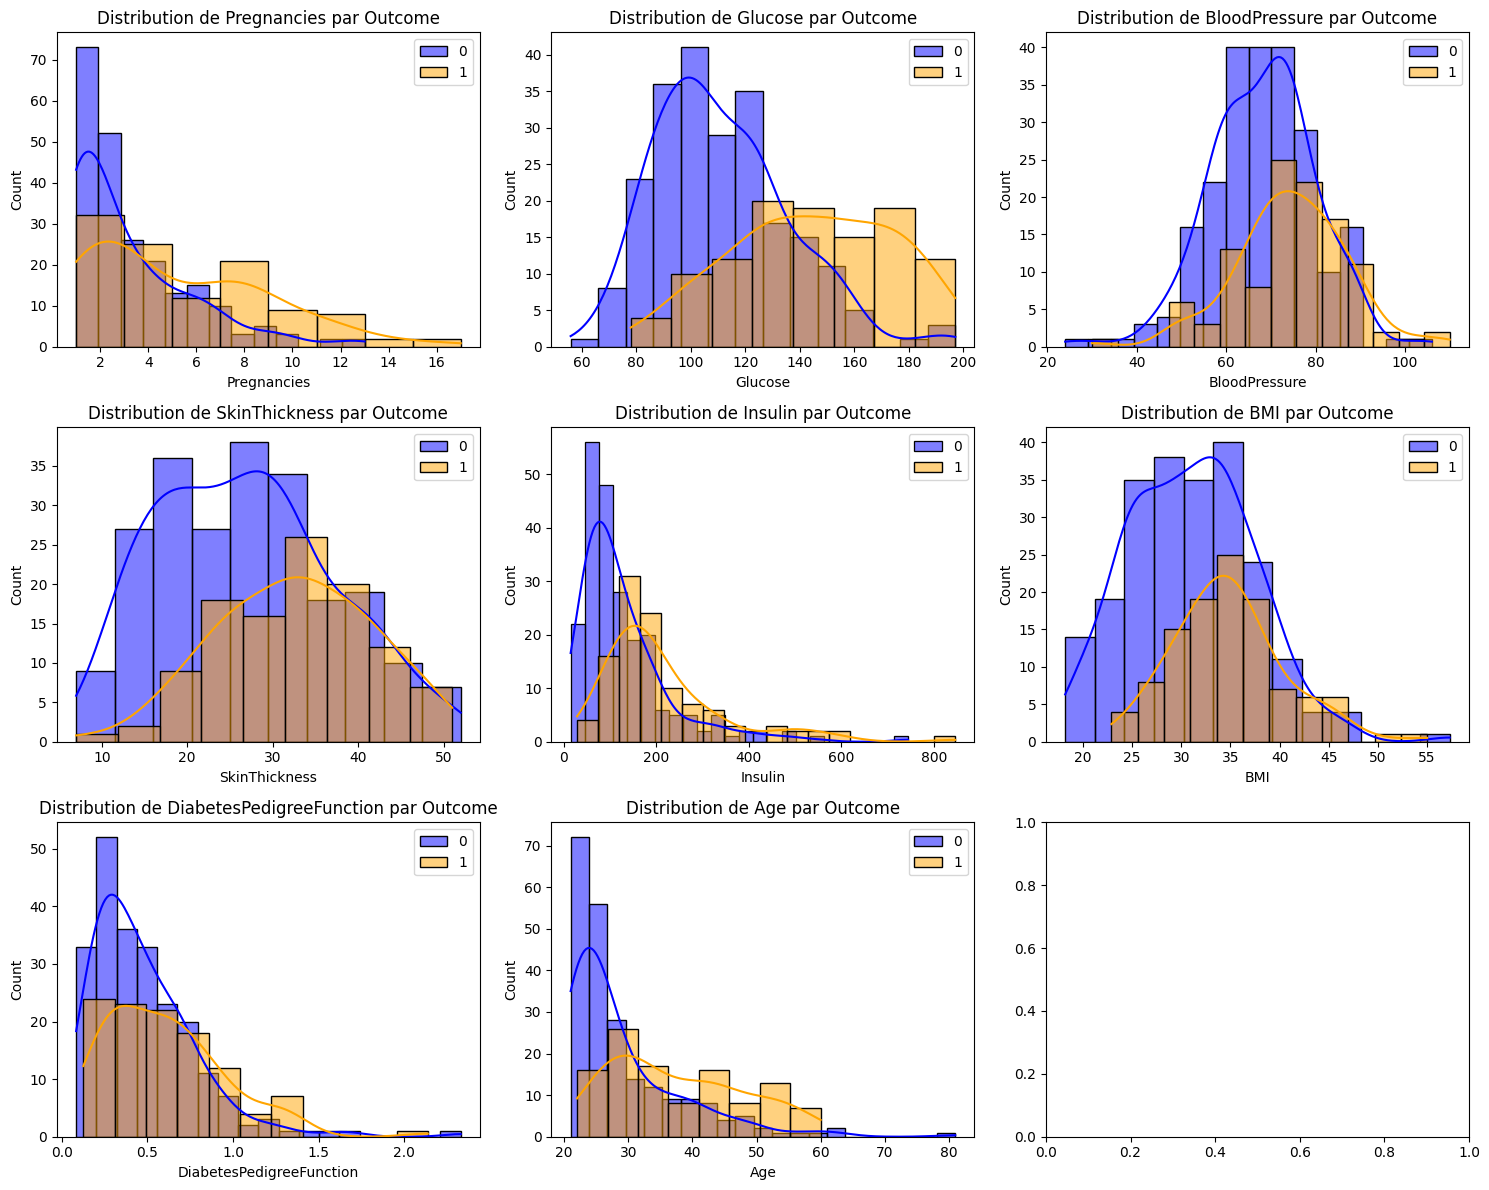

In [23]:
# Sélectionner les lignes où toutes les colonnes de features sont différentes de zéro
data_no_0 = data.loc[(data[features] != 0).all(axis=1)]


fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Aplatir la liste des axes pour itérer plus facilement
axs = axs.flatten()

for i, feature in enumerate(features):
    sns.histplot(data_no_0[data_no_0['Outcome'] == 0][feature], color='blue', kde=True, ax=axs[i], label='0')
    sns.histplot(data_no_0[data_no_0['Outcome'] == 1][feature], color='orange', kde=True, ax=axs[i], label='1')
    axs[i].set_title(f'Distribution de {feature} par Outcome')
    axs[i].legend()

plt.tight_layout()
plt.show()

In [24]:
data_no_0_outcome_0 = data_no_0[data_no_0['Outcome'] == 0]
data_no_0_outcome_1 = data_no_0[data_no_0['Outcome'] == 1]

In [25]:
# Calculer la skewness pour chaque colonne pour Outcome = 1
skewness_data_no_0_outcome_1 = data_no_0_outcome_1.apply(lambda x: skew(x.dropna()))

# Calculer la skewness pour chaque colonne pour Outcome = 0
skewness_data_no_0_outcome_0 = data_no_0_outcome_0.apply(lambda x: skew(x.dropna()))

# Afficher les résultats
print("Skewness pour Outcome = 1 :")
print(skewness_data_no_0_outcome_1)

print("\nSkewness pour Outcome = 0 :")
print(skewness_data_no_0_outcome_0)

Skewness pour Outcome = 1 :
Pregnancies                 0.767552
Glucose                    -0.177760
BloodPressure              -0.238337
SkinThickness              -0.157507
Insulin                     1.960336
BMI                         0.611624
DiabetesPedigreeFunction    1.140667
Age                         0.426204
Outcome                          NaN
dtype: float64

Skewness pour Outcome = 0 :
Pregnancies                 1.525738
Glucose                     0.718934
BloodPressure              -0.213442
SkinThickness               0.348355
Insulin                     2.417754
BMI                         0.399703
DiabetesPedigreeFunction    1.922897
Age                         2.068008
Outcome                          NaN
dtype: float64


C:\Users\corre\AppData\Local\Temp\ipykernel_26512\168784043.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness_data_no_0_outcome_1 = data_no_0_outcome_1.apply(lambda x: skew(x.dropna()))


In [26]:
''' Analyse si pregnancies = 0 ou > 0 selon outcome toujours'''

' Analyse si pregnancies = 0 ou > 0 selon outcome toujours'

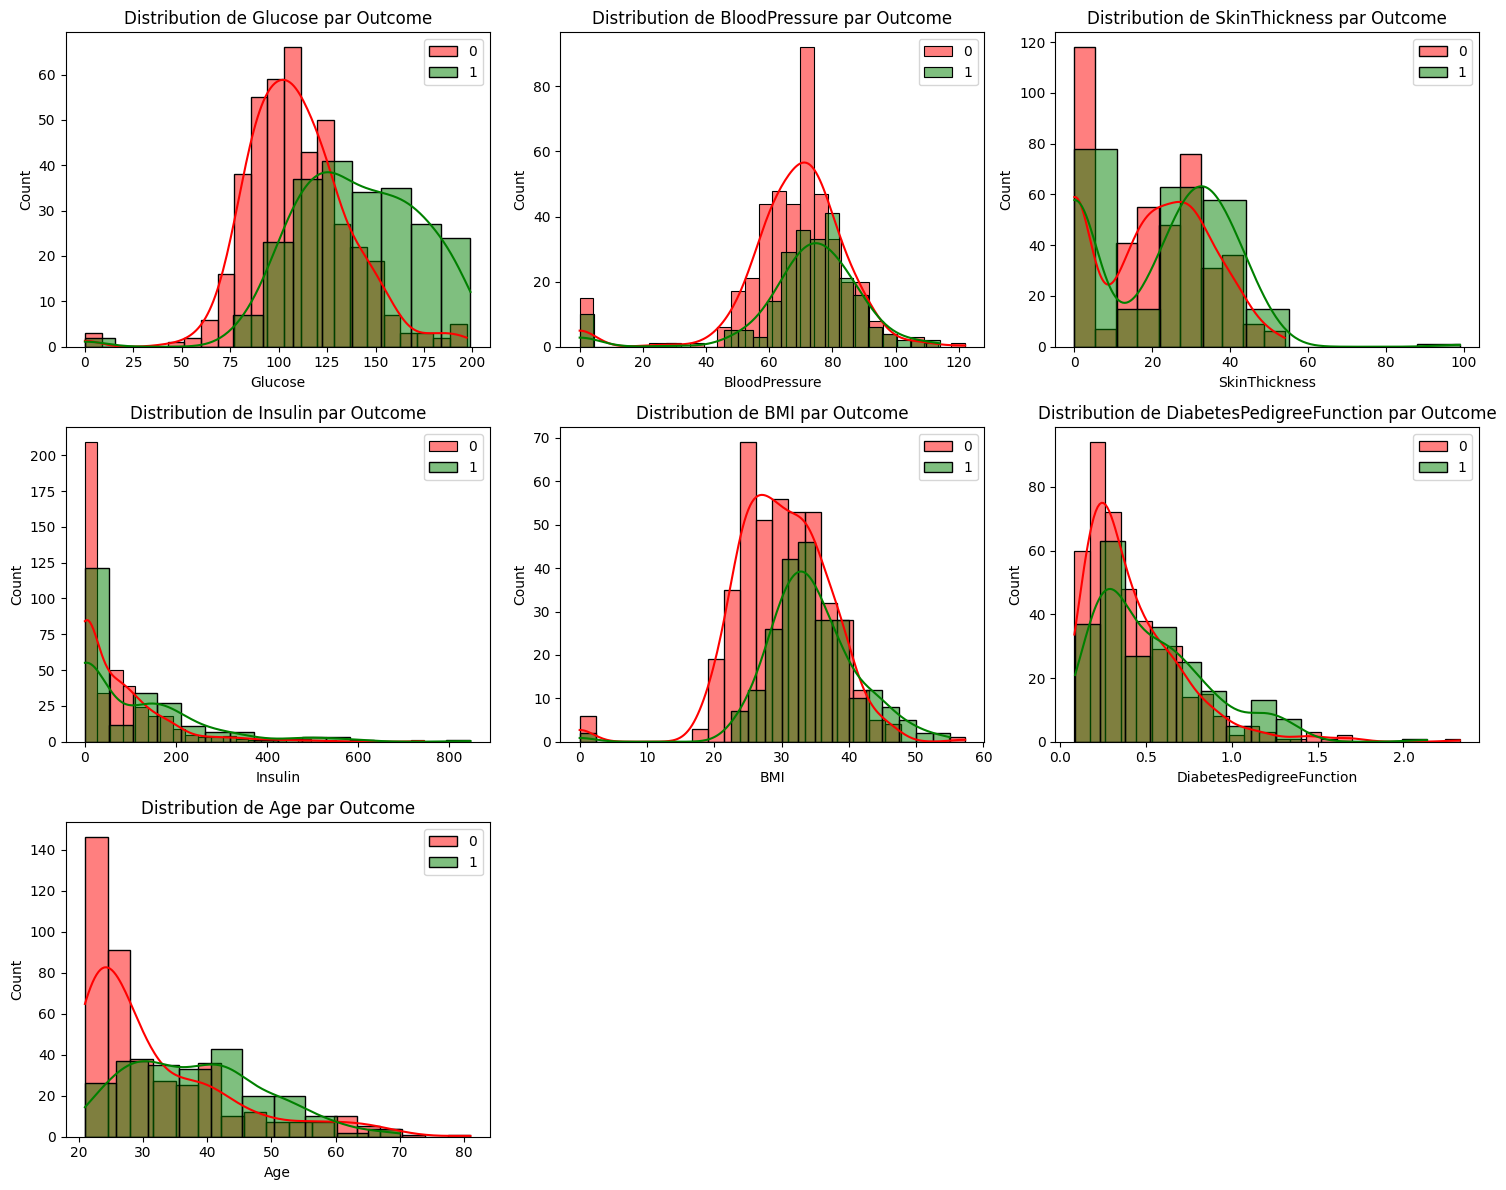

In [27]:
features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axs = axs.flatten()


# Boucle pour tracer les memes histogrammes que precedement mais que sur les personnes ayant eu au moins un enfant

for i, feature in enumerate(features):
    # Filtrer les données pour Outcome == 0 et Pregnancy >= 1
    data_filt_preg1_0 = data[(data['Outcome'] == 0) & (data['Pregnancies'] >= 1)][feature]
    # Filtrer les données pour Outcome == 1 et Pregnancy >= 1
    data_filt_preg1_1 = data[(data['Outcome'] == 1) & (data['Pregnancies'] >= 1)][feature]
    
    # Tracer les distributions pour Outcome == 0
    sns.histplot(data=data_filt_preg1_0, color='red', kde=True, ax=axs[i], label='0')
    # Tracer les distributions pour Outcome == 1
    sns.histplot(data=data_filt_preg1_1, color='green', kde=True, ax=axs[i], label='1')
    
    axs[i].set_title(f'Distribution de {feature} par Outcome')
    axs[i].legend()

# Masquer les sous-graphiques inutilisés
for j in range(len(features), len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


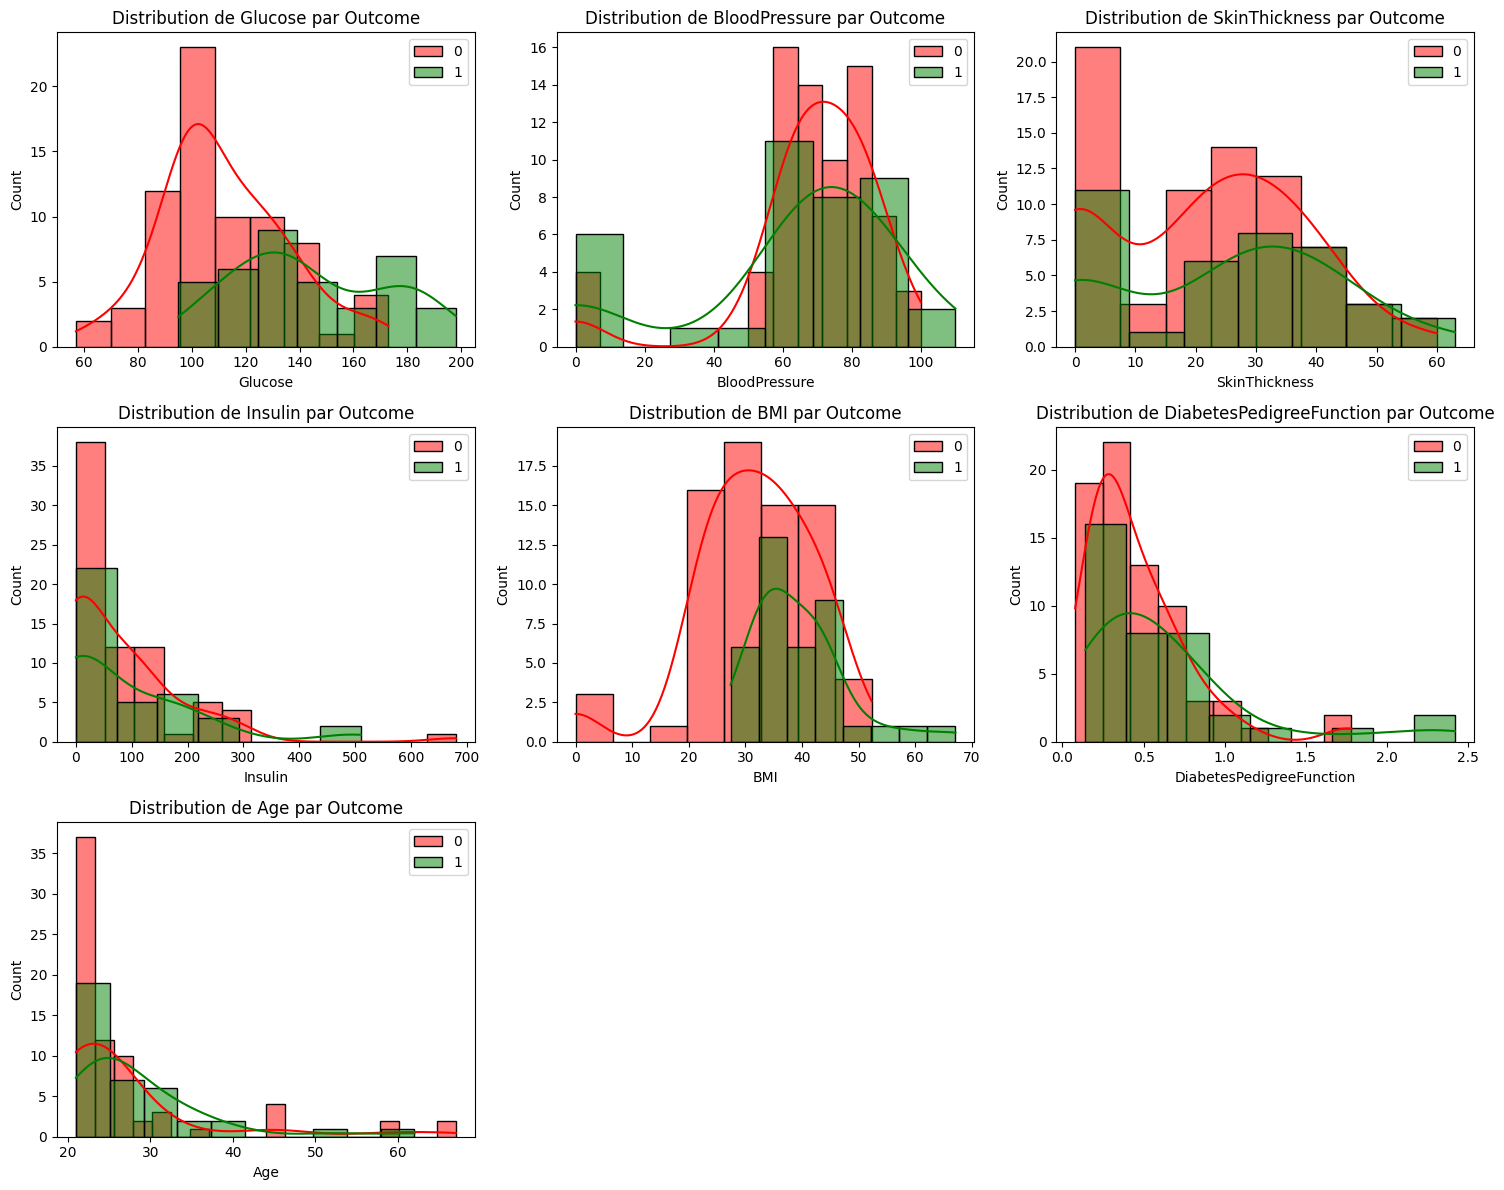

In [28]:
features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axs = axs.flatten()


# Boucle pour tracer les memes histogrammes que precedement mais que sur les personnes n'ayant pas eu d'enfant

for i, feature in enumerate(features):
    # Filtrer les données pour Outcome == 0 et Pregnancy >= 1
    data_filt_preg0_0 = data[(data['Outcome'] == 0) & (data['Pregnancies'] == 0)][feature]
    # Filtrer les données pour Outcome == 1 et Pregnancy >= 1
    data_filt_preg0_1 = data[(data['Outcome'] == 1) & (data['Pregnancies'] == 0)][feature]
    
    # Tracer les distributions pour Outcome == 0
    sns.histplot(data=data_filt_preg0_0, color='red', kde=True, ax=axs[i], label='0')
    # Tracer les distributions pour Outcome == 1
    sns.histplot(data=data_filt_preg0_1, color='green', kde=True, ax=axs[i], label='1')
    
    axs[i].set_title(f'Distribution de {feature} par Outcome')
    axs[i].legend()

# Masquer les sous-graphiques inutilisés
for j in range(len(features), len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


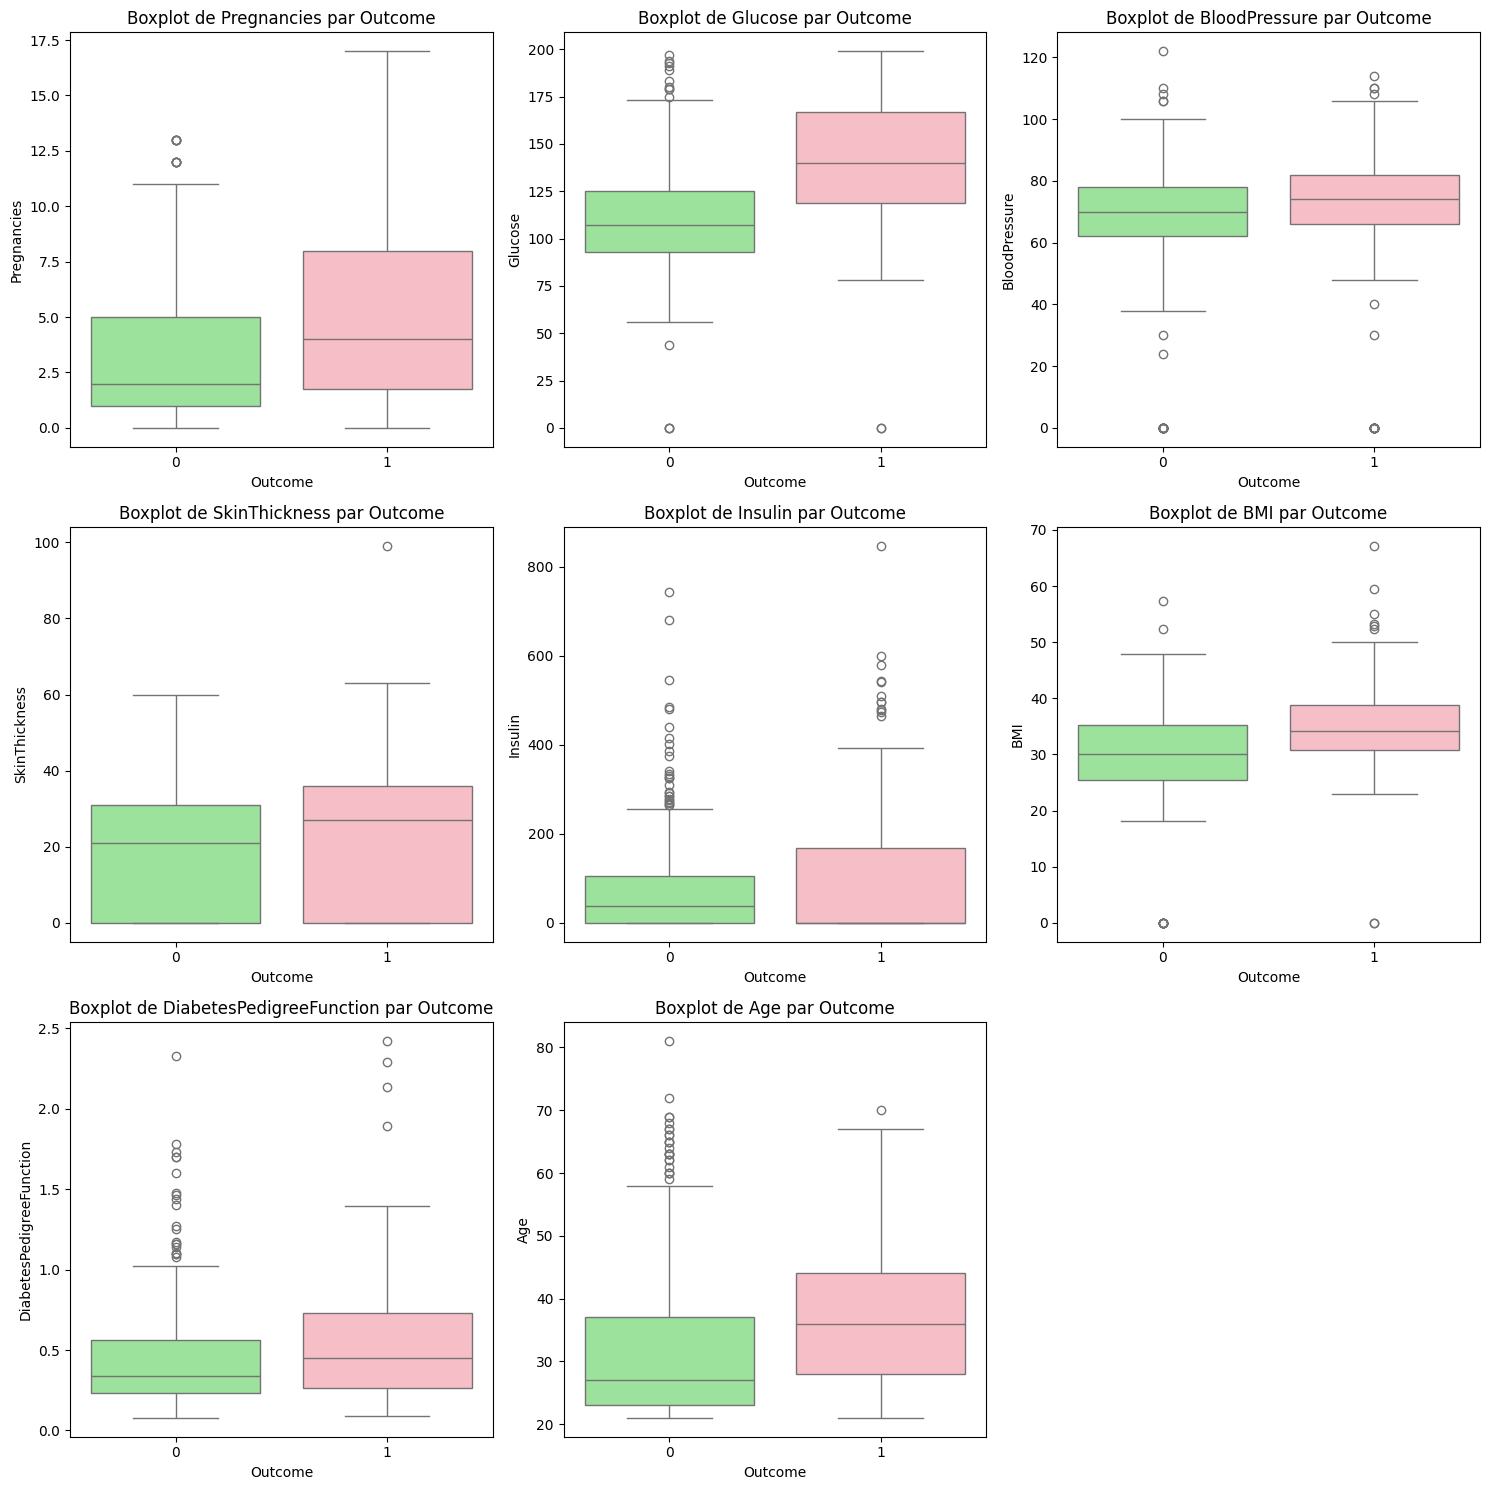

In [29]:
# Liste des caractéristiques à tracer
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

# Créer des sous-graphiques
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

# Aplatir la liste des axes pour itérer plus facilement
axs = axs.flatten()

# Parcourir chaque caractéristique et tracer les boîtes à moustaches
for i, feature in enumerate(features):
    sns.boxplot(x='Outcome', y=feature, data=data, hue='Outcome', palette=['lightgreen', 'lightpink'], ax=axs[i], legend=False)
    axs[i].set_title(f'Boxplot de {feature} par Outcome')

# Masquer les sous-graphiques inutilisés
for j in range(i+1, len(axs)):
    axs[j].axis('off')

# Ajuster les espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

In [30]:
''' Les boxplots nous permettent de voir que des valeurs sortent de l'ordinaires dans certaines lignes
    Nous allons devoir explorer ces données afin de determiner si elles sont due à la maladie ou si 
    elles sont des valeurs abérrantes à modifier ou supprimer'''

" Les boxplots nous permettent de voir que des valeurs sortent de l'ordinaires dans certaines lignes\n    Nous allons devoir explorer ces données afin de determiner si elles sont due à la maladie ou si \n    elles sont des valeurs abérrantes à modifier ou supprimer"

#### 1.2.2 - Analyse statique descriptive de base

In [31]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [32]:
data_outcome_0.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,500.000000,500.0000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0
mean,3.298000,109.9800,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000,0.0
std,3.017185,26.1412,18.063075,14.889947,98.865289,7.689855,0.299085,11.667655,0.0
min,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.0
25%,1.000000,93.0000,62.000000,0.000000,0.000000,25.400000,0.229750,23.000000,0.0
50%,2.000000,107.0000,70.000000,21.000000,39.000000,30.050000,0.336000,27.000000,0.0
75%,5.000000,125.0000,78.000000,31.000000,105.000000,35.300000,0.561750,37.000000,0.0
max,13.000000,197.0000,122.000000,60.000000,744.000000,57.300000,2.329000,81.000000,0.0


In [33]:
data_outcome_1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.0
mean,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164,1.0
std,3.741239,31.939622,21.491812,17.679711,138.689125,7.262967,0.372354,10.968254,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.088000,21.000000,1.0
25%,1.750000,119.000000,66.000000,0.000000,0.000000,30.800000,0.262500,28.000000,1.0
50%,4.000000,140.000000,74.000000,27.000000,0.000000,34.250000,0.449000,36.000000,1.0
75%,8.000000,167.000000,82.000000,36.000000,167.250000,38.775000,0.728000,44.000000,1.0
max,17.000000,199.000000,114.000000,99.000000,846.000000,67.100000,2.420000,70.000000,1.0


In [34]:
data_outcome_0['Insulin'].describe()

count    500.000000
mean      68.792000
std       98.865289
min        0.000000
25%        0.000000
50%       39.000000
75%      105.000000
max      744.000000
Name: Insulin, dtype: float64

In [35]:
data_outcome_0[data_outcome_0['Insulin'] != 0].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.0
mean,2.704545,111.034091,68.969697,27.208333,130.287879,31.615152,0.476280,28.291667,0.0
std,2.615364,25.491868,11.855556,10.407211,102.482237,7.049650,0.308198,8.977484,0.0
min,0.000000,0.000000,24.000000,7.000000,15.000000,0.000000,0.085000,21.000000,0.0
25%,1.000000,94.000000,60.000000,18.750000,66.000000,26.075000,0.261000,22.000000,0.0
50%,2.000000,107.500000,70.000000,27.000000,102.500000,31.200000,0.413500,25.000000,0.0
75%,4.000000,126.000000,76.000000,34.000000,161.250000,36.100000,0.626750,30.000000,0.0
max,13.000000,197.000000,106.000000,60.000000,744.000000,57.300000,2.329000,81.000000,0.0


### 1.3 - Observation des variables catégoritielles

#### 1.3.1 - Analyse du nombre de valeurs unique

In [36]:
data.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

#### 1.3.2 - Analyse des  statistique de base

In [37]:
# alpha=0.5 : Définit la transparence des points. 
# Une valeur de 0.5 signifie que les points seront semi-transparents, 
# ce qui aide à visualiser les zones avec une densité de points élevée.
# s=50 : Définit la taille des points. Une taille de 50 rend les points 
# suffisamment grands pour être visibles, mais pas trop gros pour ne pas encombrer le graphique.

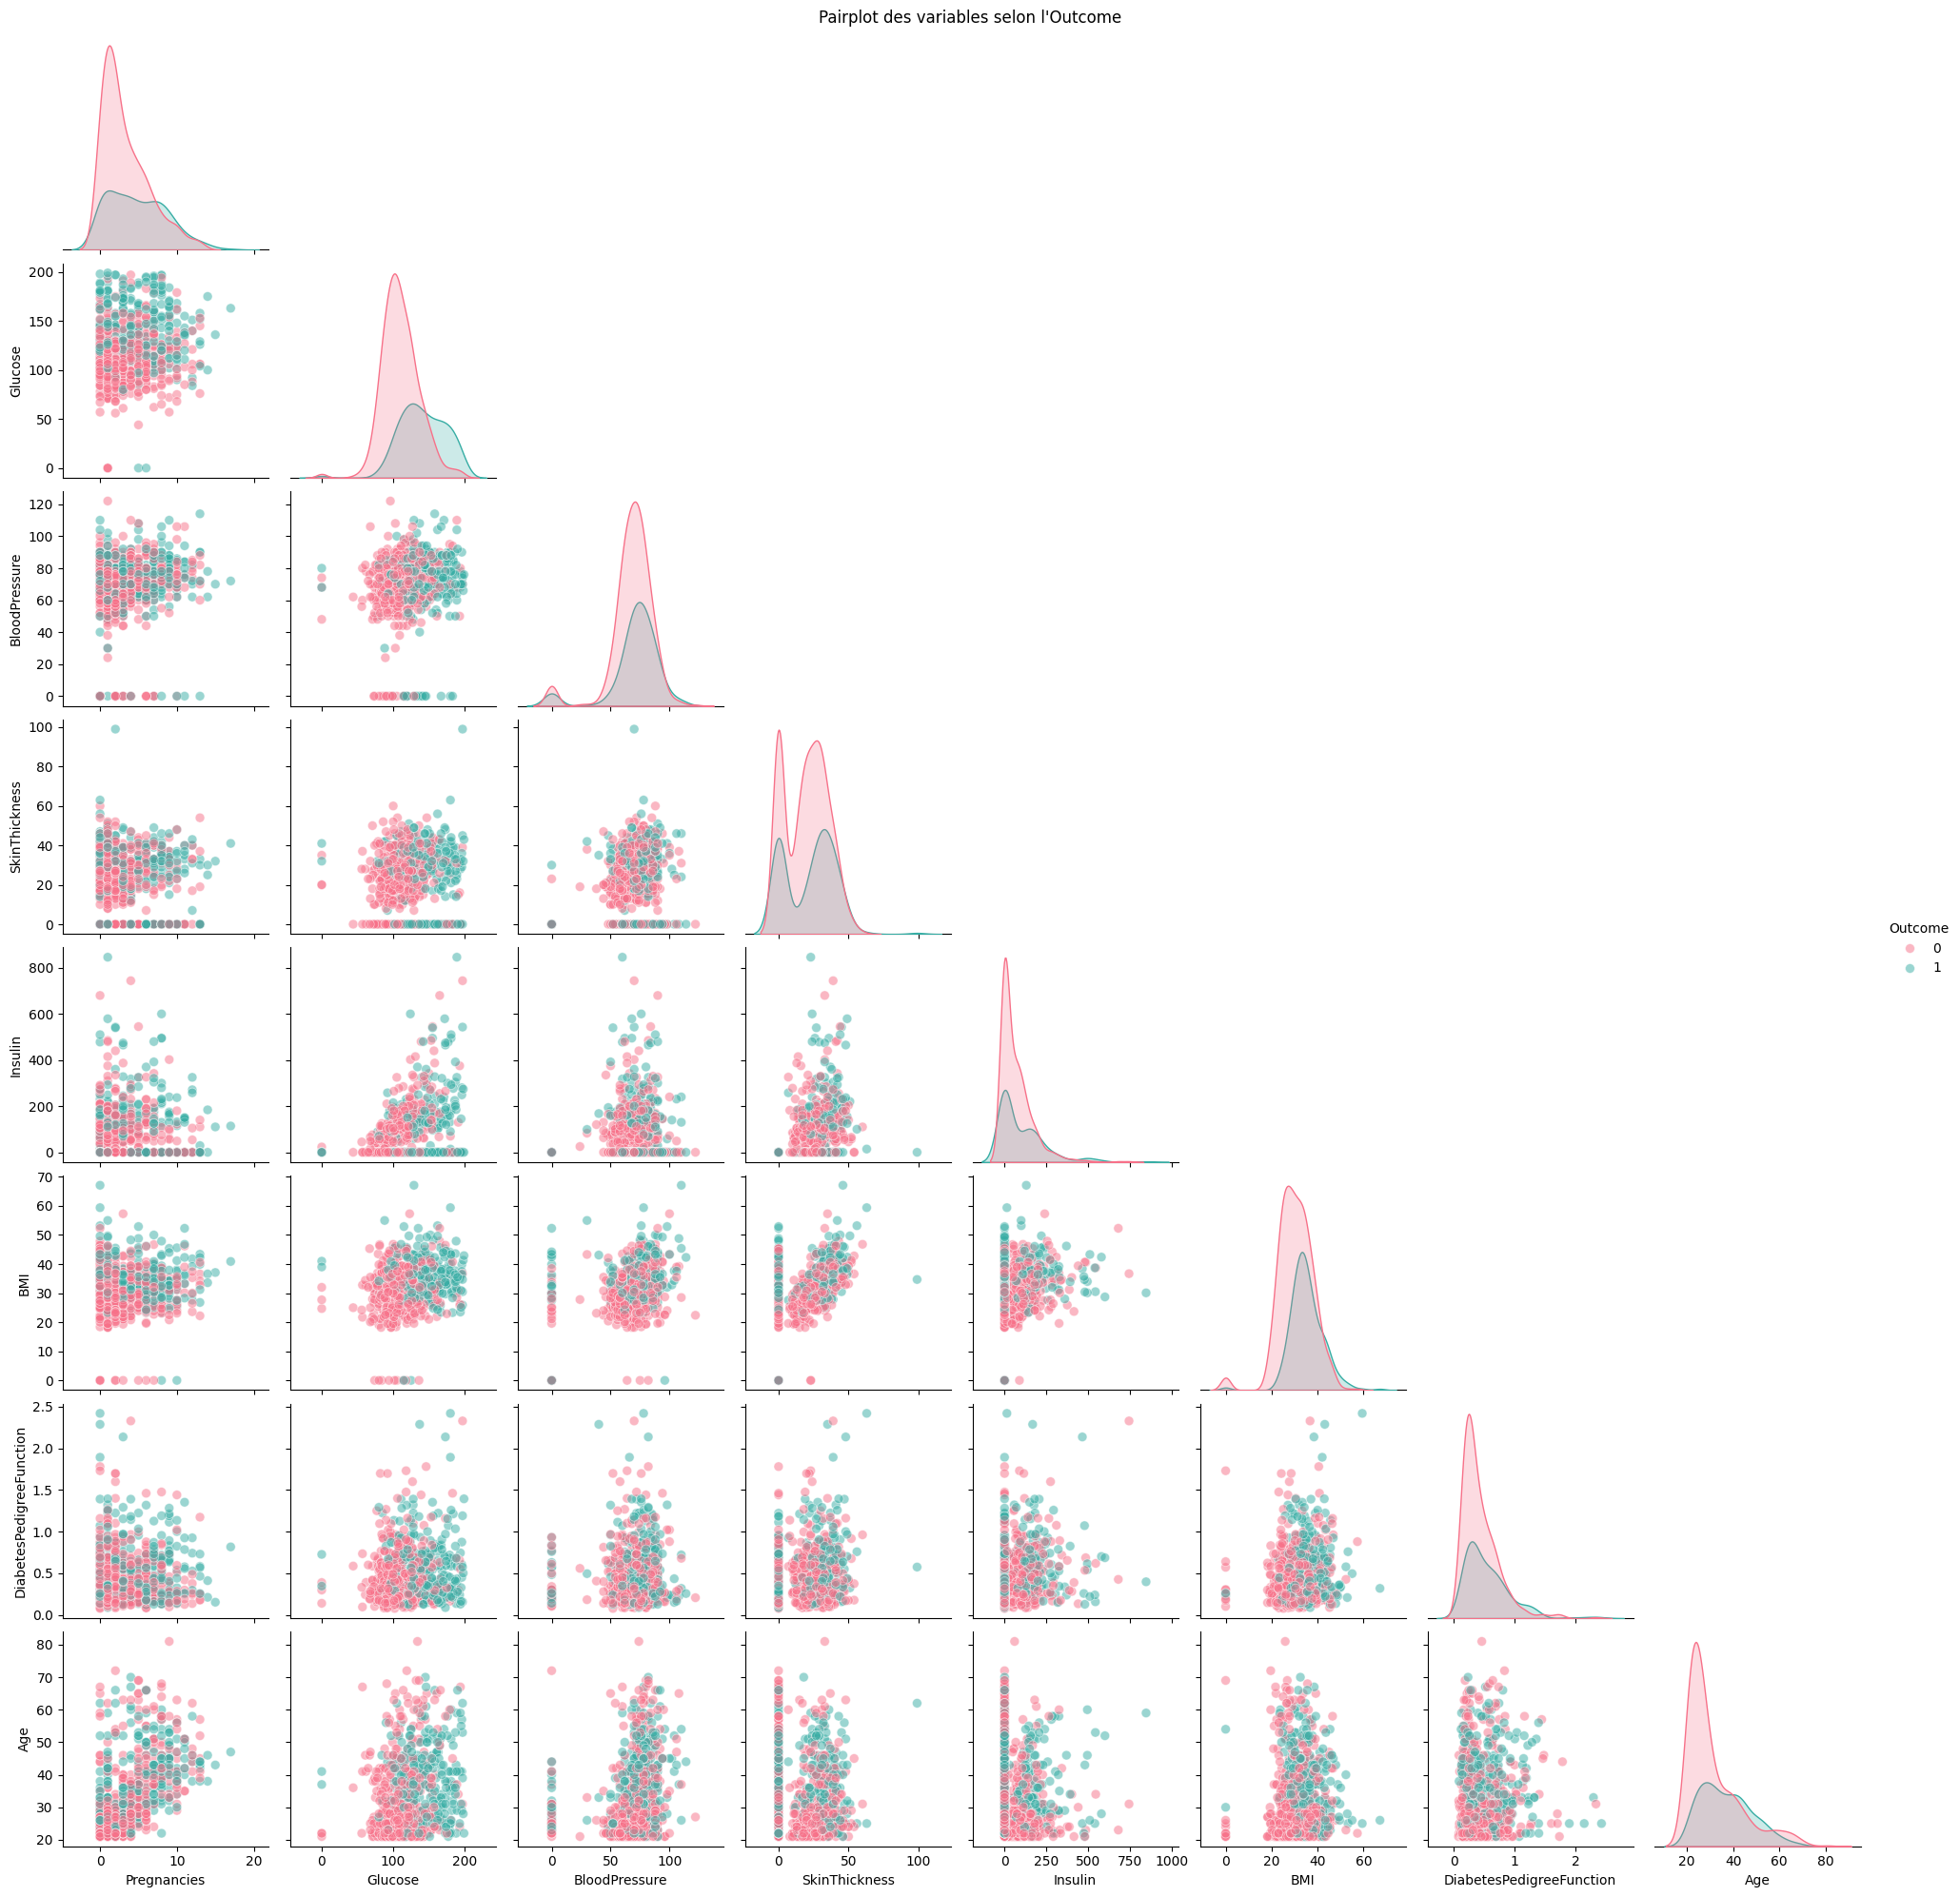

In [38]:
# Créer le pairplot avec une palette de couleurs et en mode "corner" = sans doublons
pairplot = sns.pairplot(data, hue="Outcome", palette="husl", plot_kws={'alpha':0.5, 's':50}, corner=True)

pairplot.fig.suptitle('Pairplot des variables selon l\'Outcome', y=1)  #y=1 placement du titre en haut 
plt.show()

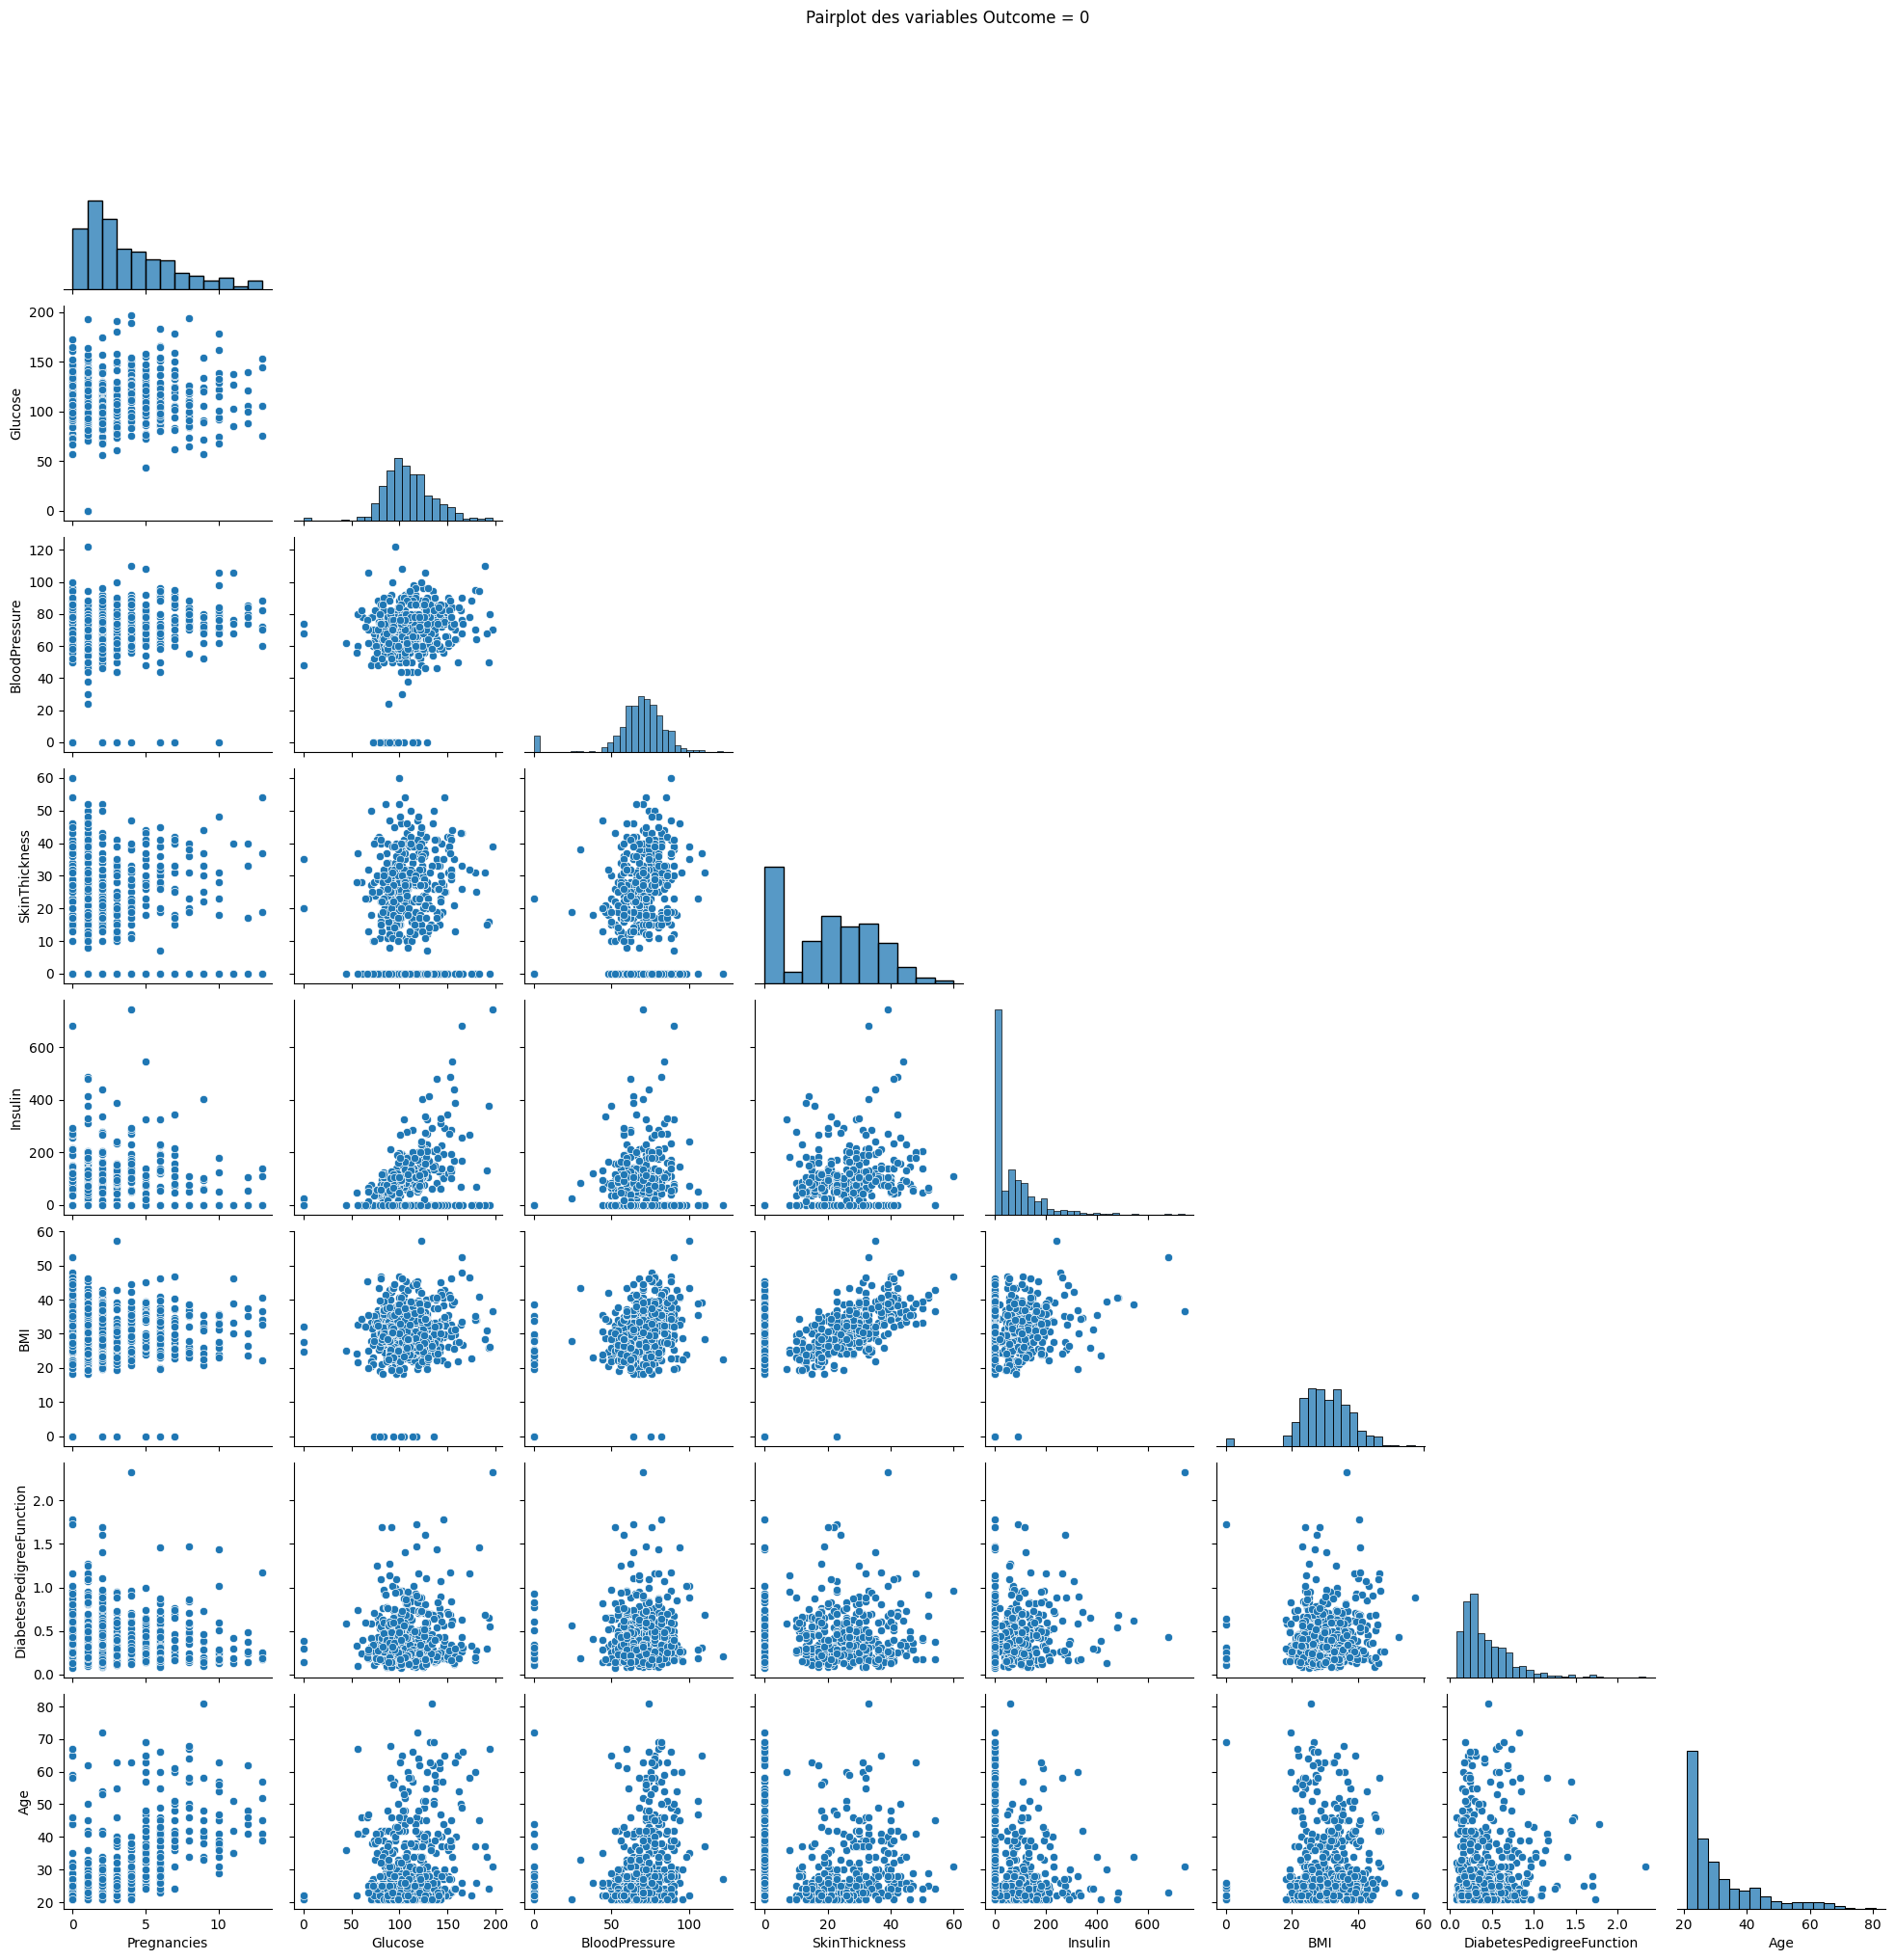

In [39]:
# Créer le pairplot en mode "corner"
pairplot = sns.pairplot(data_outcome_0.drop(columns = "Outcome"), corner=True)

pairplot.fig.suptitle('Pairplot des variables Outcome = 0', y=1.02)  # y=1.02 pour placer le titre en haut

plt.show()

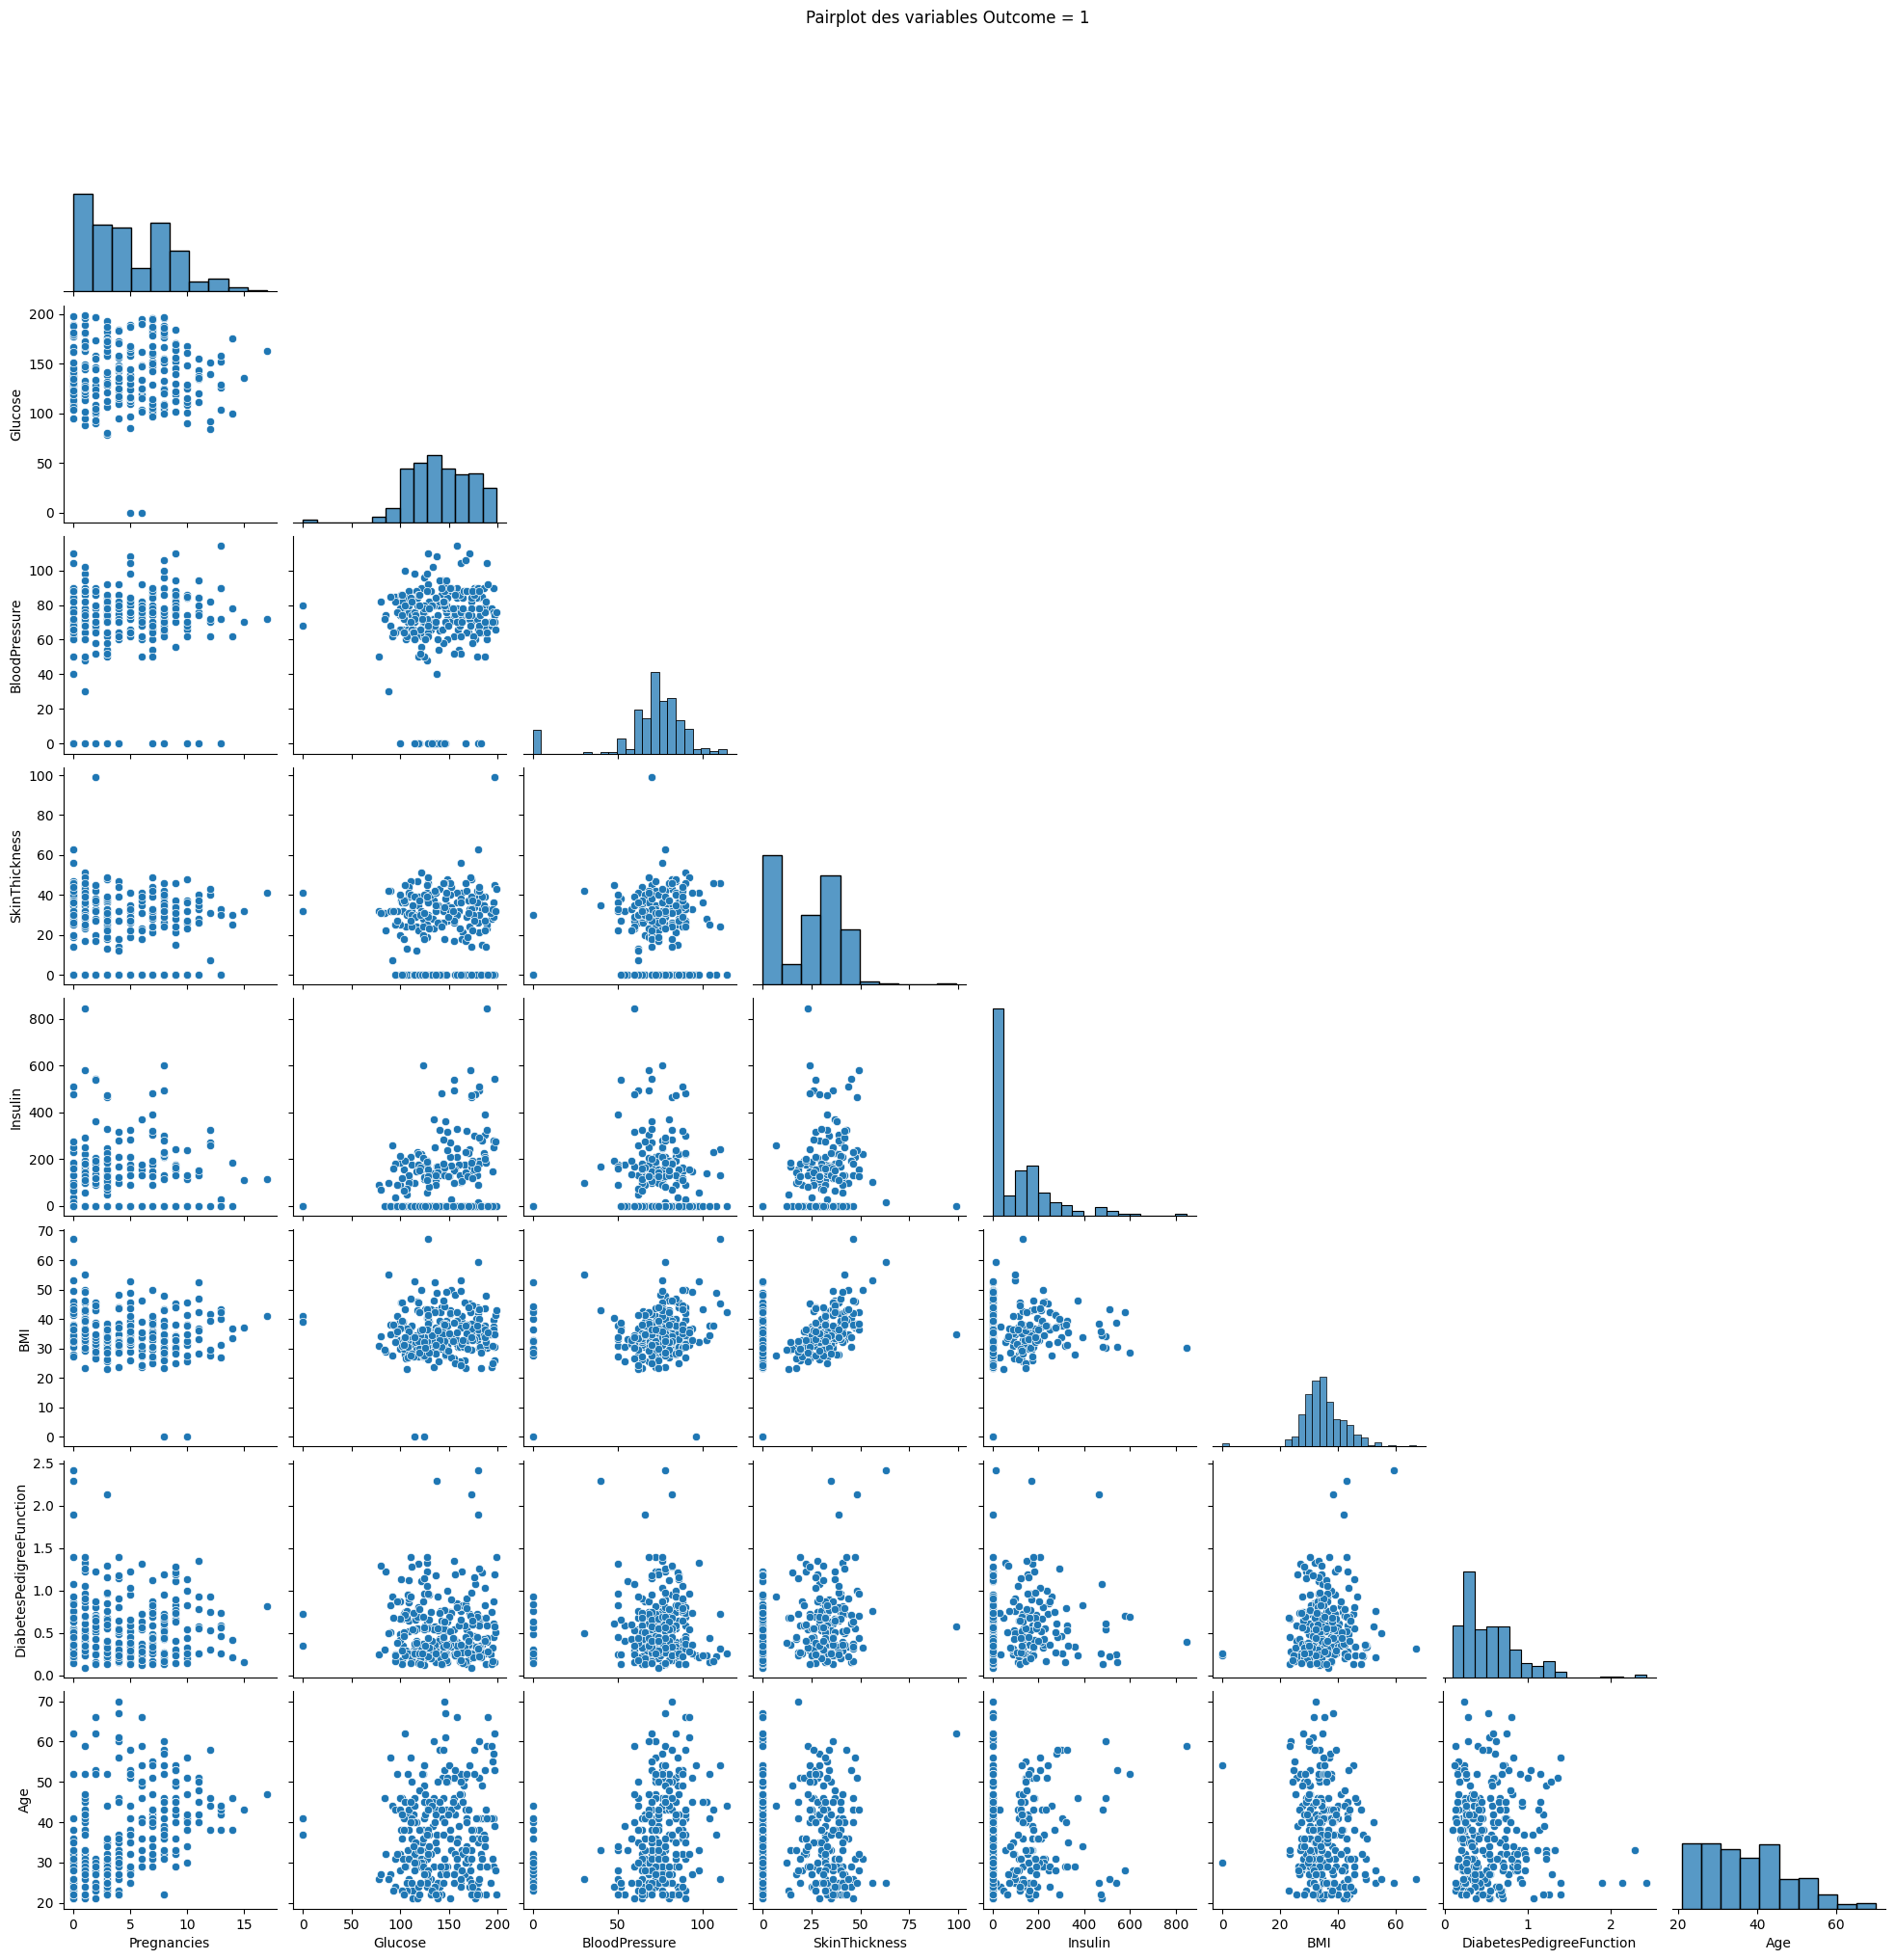

In [40]:
# Créer le pairplot en mode "corner"
pairplot = sns.pairplot(data_outcome_1.drop(columns = "Outcome"), corner=True)

pairplot.fig.suptitle('Pairplot des variables Outcome = 1', y=1.02)  # y=1.02 pour placer le titre en haut

plt.show()

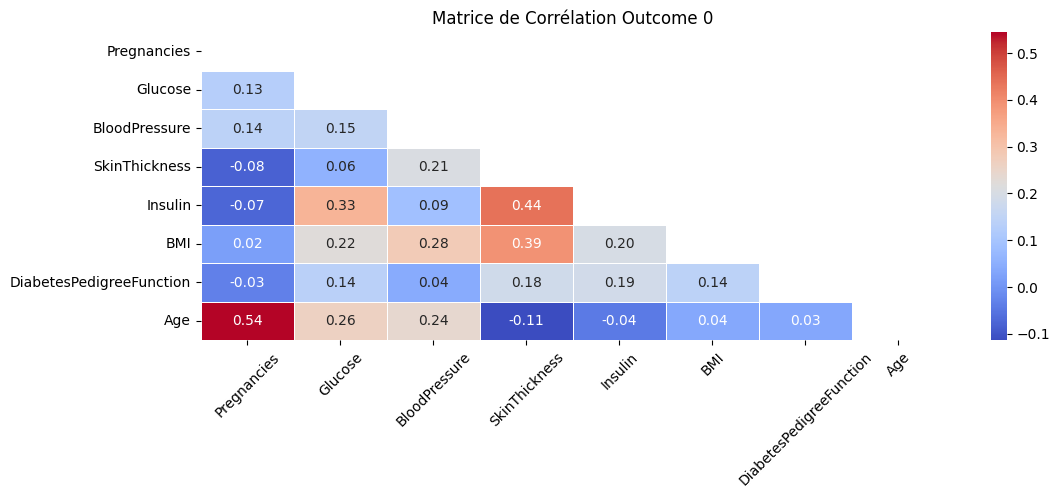

In [41]:
# Calculer la matrice de corrélation
correlation_matrix = data.drop(columns = "Outcome").corr()

# Créer un masque pour masquer la partie inférieure de la matrice de corrélation
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Visualiser la matrice de corrélation
plt.figure(figsize=(12, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
plt.title('Matrice de Corrélation Outcome 0')
plt.xticks(rotation=45)
plt.show()

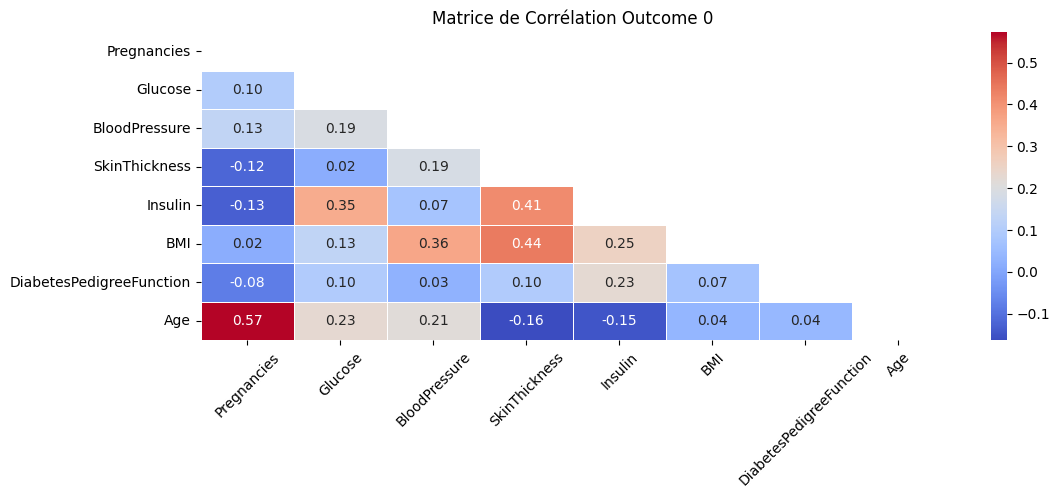

In [42]:
# Calculer la matrice de corrélation
correlation_matrix_0 = data_outcome_0.drop(columns = "Outcome").corr()

# Créer un masque pour masquer la partie inférieure de la matrice de corrélation
mask = np.triu(np.ones_like(correlation_matrix_0, dtype=bool))

# Visualiser la matrice de corrélation
plt.figure(figsize=(12, 4))
sns.heatmap(correlation_matrix_0, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
plt.title('Matrice de Corrélation Outcome 0')
plt.xticks(rotation=45)
plt.show()

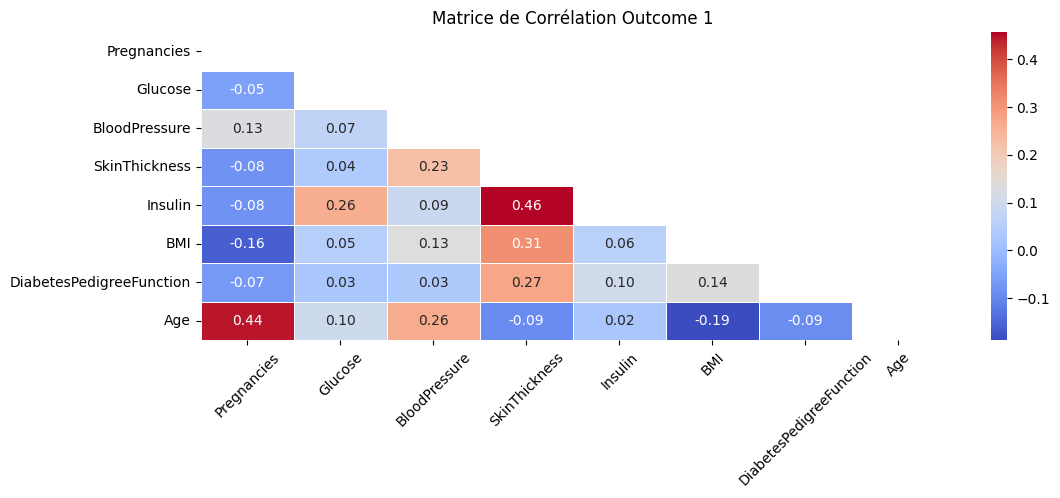

In [43]:
# Calculer la matrice de corrélation
correlation_matrix_1 = data_outcome_1.drop(columns = "Outcome").corr()

# Créer un masque pour masquer la partie inférieure de la matrice de corrélation
mask = np.triu(np.ones_like(correlation_matrix_1, dtype=bool))

# Visualiser la matrice de corrélation
plt.figure(figsize=(12, 4))
sns.heatmap(correlation_matrix_1, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
plt.xticks(rotation=45)
plt.title('Matrice de Corrélation Outcome 1')
plt.show()

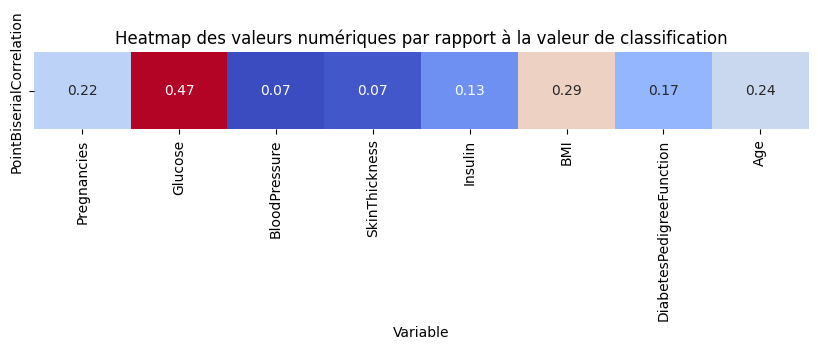

In [44]:
continuous_cols = data.drop(columns = "Outcome")

correlations = {}
for col in continuous_cols.columns:

    correlations[col] = pointbiserialr(data['Outcome'], data[col])[0]

corr_df = pd.DataFrame(list(correlations.items()), columns=['Variable', 'PointBiserialCorrelation'])
corr_df.set_index('Variable', inplace=True)

plt.figure(figsize=(10, 1))

sns.heatmap(corr_df.T, annot=True, cmap='coolwarm', cbar=False, fmt=".2f")
plt.title('Heatmap des valeurs numériques par rapport à la valeur de classification')

plt.show()

In [45]:
'''

Le coefficient de corrélation de Pearson est une formule qui permet de quantifier la relation
linéaire entre deux variables : le coefficient est un réel entre -1 et 1 avec :

1 les variables sont corrélées

0 les variables sont décorrélées

-1 les variables sont corrélées négativement

Pour rejeter ou non cette hypothèse, on regarde la p-value du test : i cette dernière est en dessous de 5%, on rejette H0.

'''

'\n\nLe coefficient de corrélation de Pearson est une formule qui permet de quantifier la relation\nlinéaire entre deux variables : le coefficient est un réel entre -1 et 1 avec :\n\n1 les variables sont corrélées\n\n0 les variables sont décorrélées\n\n-1 les variables sont corrélées négativement\n\nPour rejeter ou non cette hypothèse, on regarde la p-value du test : i cette dernière est en dessous de 5%, on rejette H0.\n\n'

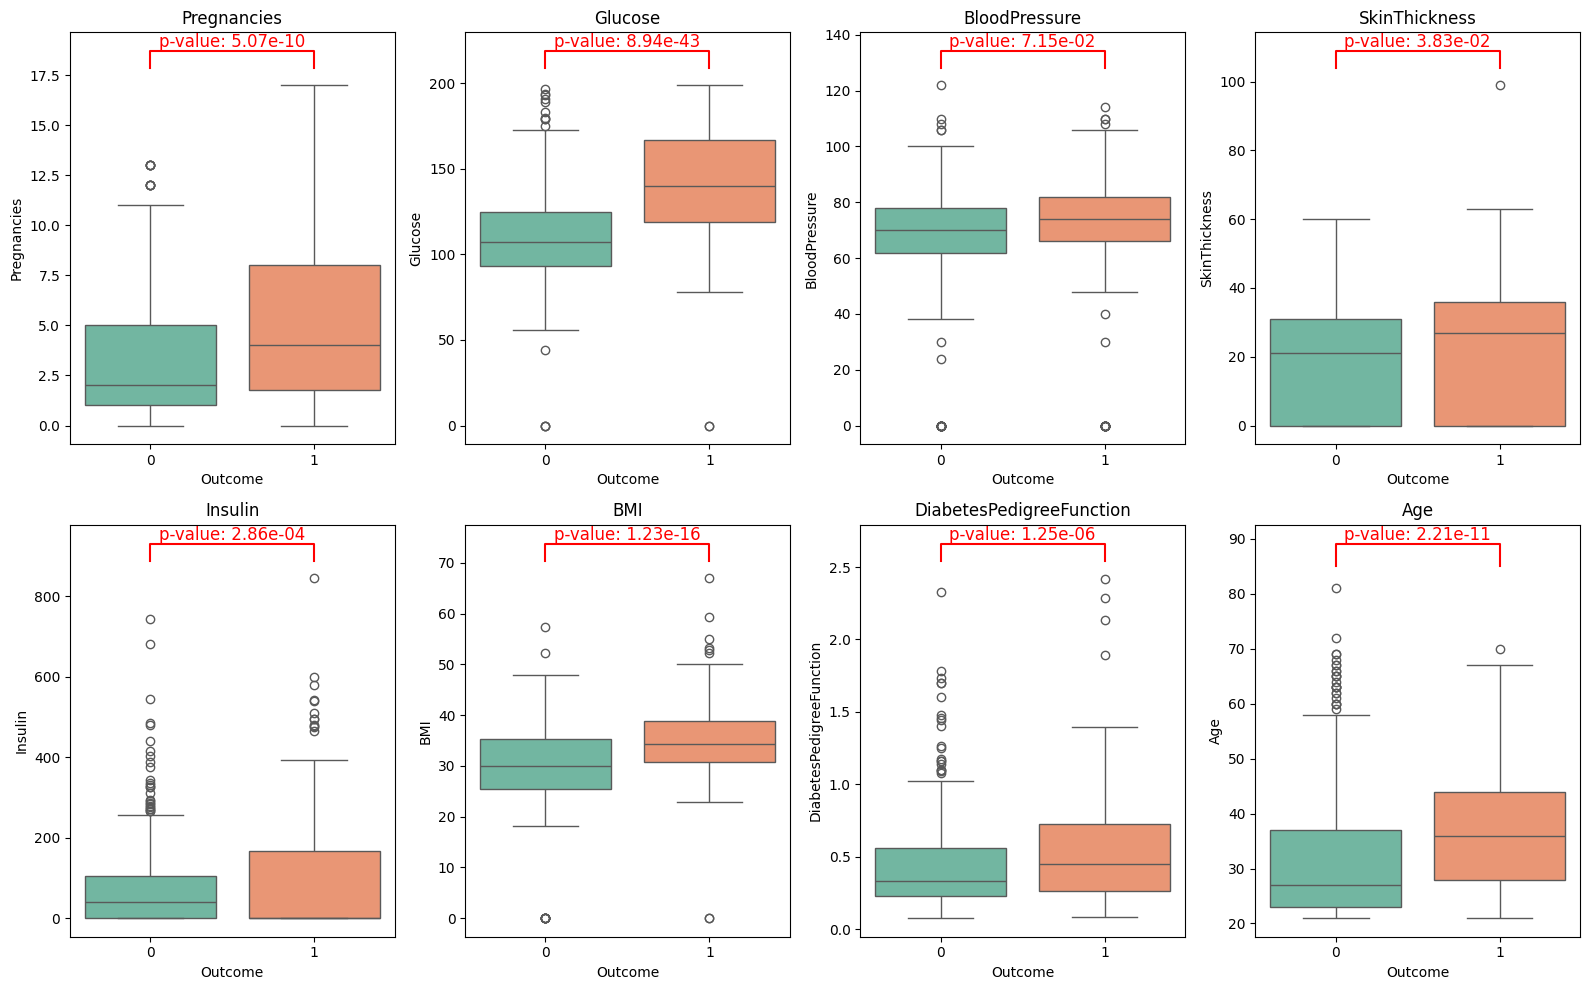

In [46]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Définir la palette de couleurs avec deux couleurs distinctes pour les deux niveaux de 'Outcome'
palette = sns.color_palette("Set2", 2)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x=data['Outcome'], y=feature, data=data, ax=axes[i], palette=palette, hue='Outcome', legend=False)
    t_stat, p_value = ttest_ind(data[data['Outcome'] == 0][feature], data[data['Outcome'] == 1][feature]) 
    # Uniquement de la mise en page
    # calcul la valeur max pour positionner la legende au dessus   
    max_value = data[feature].max()
    y, h = max_value + (max_value * 0.05), max_value * 0.05
    axes[i].plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=1.5, c='red')
    axes[i].text(0.5, y+h, f'p-value: {p_value:.2e}', ha='center', va='bottom', color='red', fontsize=12)
    axes[i].set_title(feature)


plt.tight_layout()
plt.show()

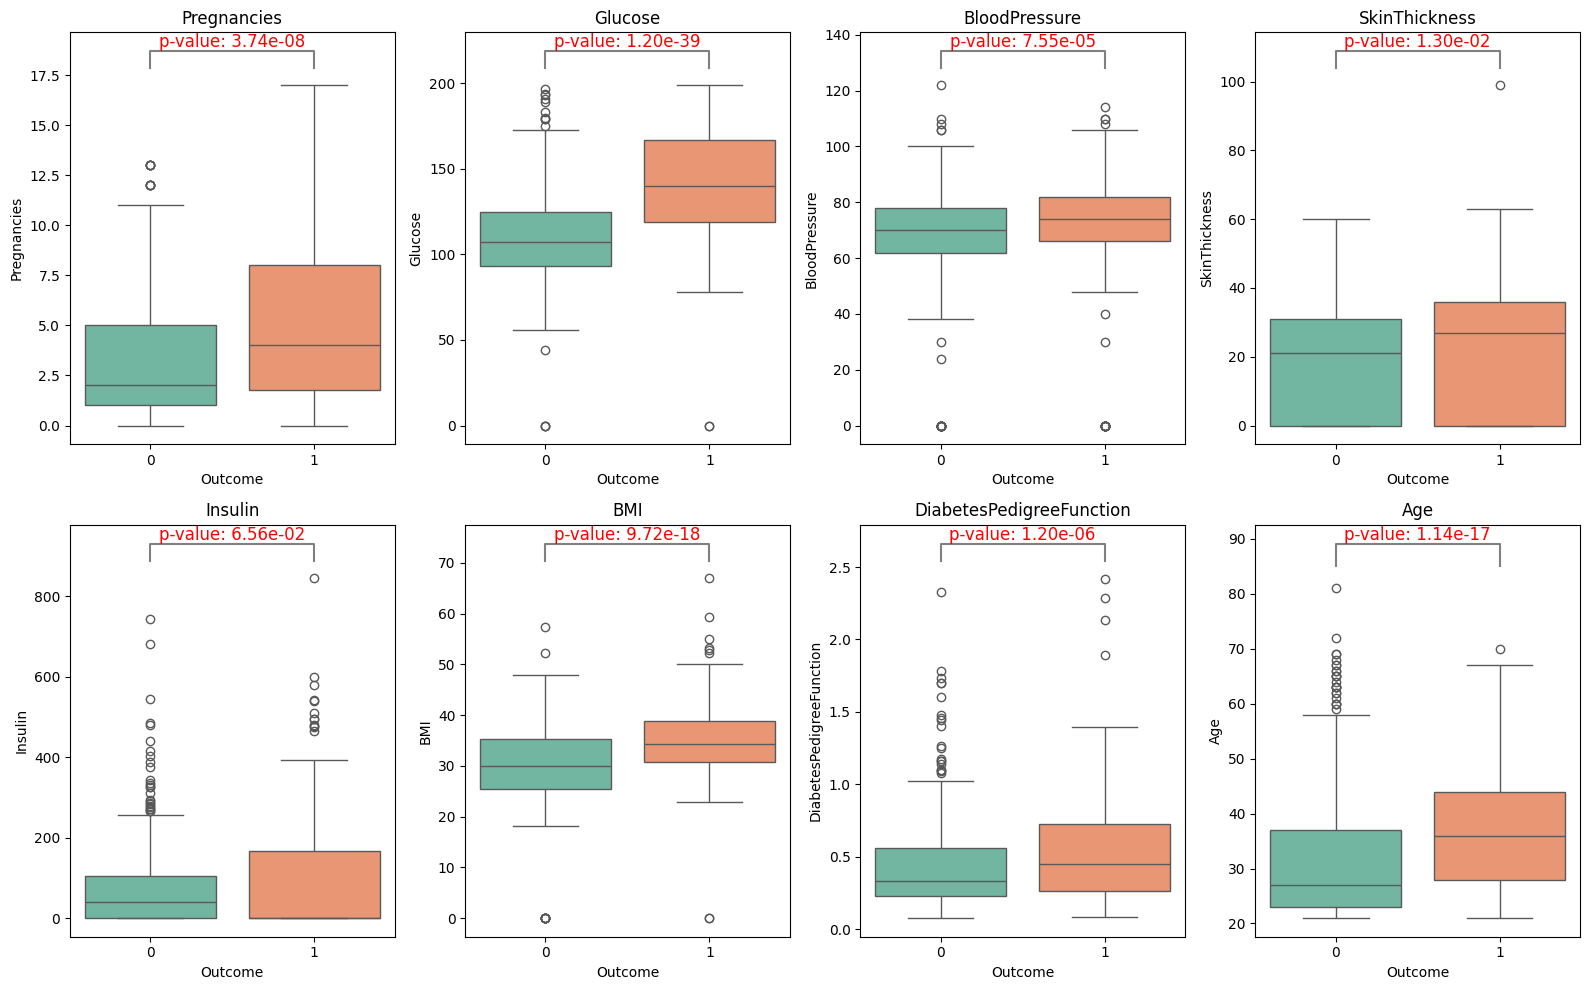

In [47]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Définir la palette de couleurs avec deux couleurs distinctes pour les deux niveaux de 'Outcome'
palette = sns.color_palette("Set2", 2)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x=data['Outcome'], y=feature, data=data, ax=axes[i], palette=palette, hue='Outcome', legend=False)
    
    # Effectuer le test de Kruskal-Wallis et obtenir la p-value
    stat, pvalue = kruskal(data[data['Outcome'] == 0][feature], data[data['Outcome'] == 1][feature])
    
    # Trouver la valeur maximale pour ajuster l'annotation
    max_value = data[feature].max()
    
    # Dessiner une ligne au-dessus du graphique pour la p-value
    y, h = max_value + (max_value * 0.05), max_value * 0.05
    axes[i].plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=1.5, color='gray')  # Gray line for significance
    axes[i].text(0.5, y+h, f'p-value: {pvalue:.2e}', ha='center', va='bottom', color='red', fontsize=12)
    
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

## 2 - Nettoyage des données

### 2.1 - Traitement des valeurs manquantes

In [48]:
'''     Interprétation des résultats :

        Skewness pour Outcome = 1 :
        Pregnancies : Skewness de 0.500925, indiquant une légère asymétrie positive.
        Glucose : Skewness de -0.492779, indiquant une légère asymétrie négative.
        BloodPressure : Skewness de -1.932738, indiquant une asymétrie négative plus prononcée.
        SkinThickness : Skewness de 0.115260, indiquant une légère asymétrie positive.
        Insulin : Skewness de 1.833495, indiquant une forte asymétrie positive.
        BMI : Skewness de 0.000593, indiquant une quasi-symétrie (très proche de zéro).
        DiabetesPedigreeFunction : Skewness de 1.712718, indiquant une forte asymétrie positive.
        Age : Skewness de 0.578385, indiquant une asymétrie positive modérée.
       
        Skewness pour Outcome = 0 :
        Pregnancies : Skewness de 1.110760, indiquant une asymétrie positive.
        Glucose : Skewness de 0.172591, indiquant une légère asymétrie positive.
        BloodPressure : Skewness de -1.804391, indiquant une asymétrie négative assez prononcée.
        SkinThickness : Skewness de 0.031062, indiquant une légère asymétrie positive.
        Insulin : Skewness de 2.491239, indiquant une forte asymétrie positive.
        BMI : Skewness de -0.663903, indiquant une asymétrie négative.
        DiabetesPedigreeFunction : Skewness de 2.000218, indiquant une forte asymétrie positive.
        Age : Skewness de 1.566891, indiquant une asymétrie positive.

        Conclusion :
        
        Les variables telles que Insulin, DiabetesPedigreeFunction et BloodPressure montrent une forte asymétrie positive dans les deux groupes.
        BMI semble être la variable la plus symétrique, avec une skewness proche de zéro dans les deux groupes.
        Les variables comme Glucose, Age et Pregnancies montrent une asymétrie positive modérée à légère.
        BloodPressure montre une asymétrie négative assez prononcée dans les deux groupes.
'''


'     Interprétation des résultats :\n\n        Skewness pour Outcome = 1 :\n        Pregnancies : Skewness de 0.500925, indiquant une légère asymétrie positive.\n        Glucose : Skewness de -0.492779, indiquant une légère asymétrie négative.\n        BloodPressure : Skewness de -1.932738, indiquant une asymétrie négative plus prononcée.\n        SkinThickness : Skewness de 0.115260, indiquant une légère asymétrie positive.\n        Insulin : Skewness de 1.833495, indiquant une forte asymétrie positive.\n        BMI : Skewness de 0.000593, indiquant une quasi-symétrie (très proche de zéro).\n        DiabetesPedigreeFunction : Skewness de 1.712718, indiquant une forte asymétrie positive.\n        Age : Skewness de 0.578385, indiquant une asymétrie positive modérée.\n       \n        Skewness pour Outcome = 0 :\n        Pregnancies : Skewness de 1.110760, indiquant une asymétrie positive.\n        Glucose : Skewness de 0.172591, indiquant une légère asymétrie positive.\n        BloodPr

In [49]:
# Traitement pour la colonne Glucose :
# Pour Outcome = 0 >         Glucose : Skewness de 0.172591, proche de 0. > moyenne
# Pour Outcome = 1 >         Glucose : Skewness de -0.492779, proche de 0 > moyenne


mean_glucose_0 = int(round(data_outcome_0['Glucose'].mean()))
mean_glucose_1 = int(round(data_outcome_1['Glucose'].mean()))


data.loc[(data['Outcome'] == 0) & (data['Glucose'] == 0), 'Glucose'] = mean_glucose_0
data.loc[(data['Outcome'] == 1) & (data['Glucose'] == 0), 'Glucose'] = mean_glucose_1



In [50]:
# Traitement pour la colonne BloodPressure :
# Pour Outcome = 0 >    BloodPressure : x > abs(1)> mediane
# Pour Outcome = 1 >    BloodPressure : x > abs(1) > mediane

median_BloodPressure_0 = int(round(data_outcome_0['BloodPressure'].median()))
median_BloodPressure_1 = int(round(data_outcome_1['BloodPressure'].median()))

data.loc[(data['Outcome'] == 0) & (data['BloodPressure'] == 0), 'BloodPressure'] = median_BloodPressure_0
data.loc[(data['Outcome'] == 1) & (data['BloodPressure'] == 0), 'BloodPressure'] = median_BloodPressure_1


In [51]:
# Traitement pour la colonne BloodPressure :
# Pour Outcome = 0 >    BMI : Skewness de -0.663903, indiquant une asymétrie négative.  > proche de 0 > moyenne
# Pour Outcome = 1 >    BMI : Skewness de 0.000593, indiquant une quasi-symétrie (très proche de zéro). > moyenne

mean_BMI_0 = data_outcome_0['BMI'].mean()
mean_BMI_1 = data_outcome_1['BMI'].mean()

data.loc[(data['Outcome'] == 0) & (data['BMI'] == 0), 'BMI'] = mean_BMI_0
data.loc[(data['Outcome'] == 1) & (data['BMI'] == 0), 'BMI'] = mean_BMI_1

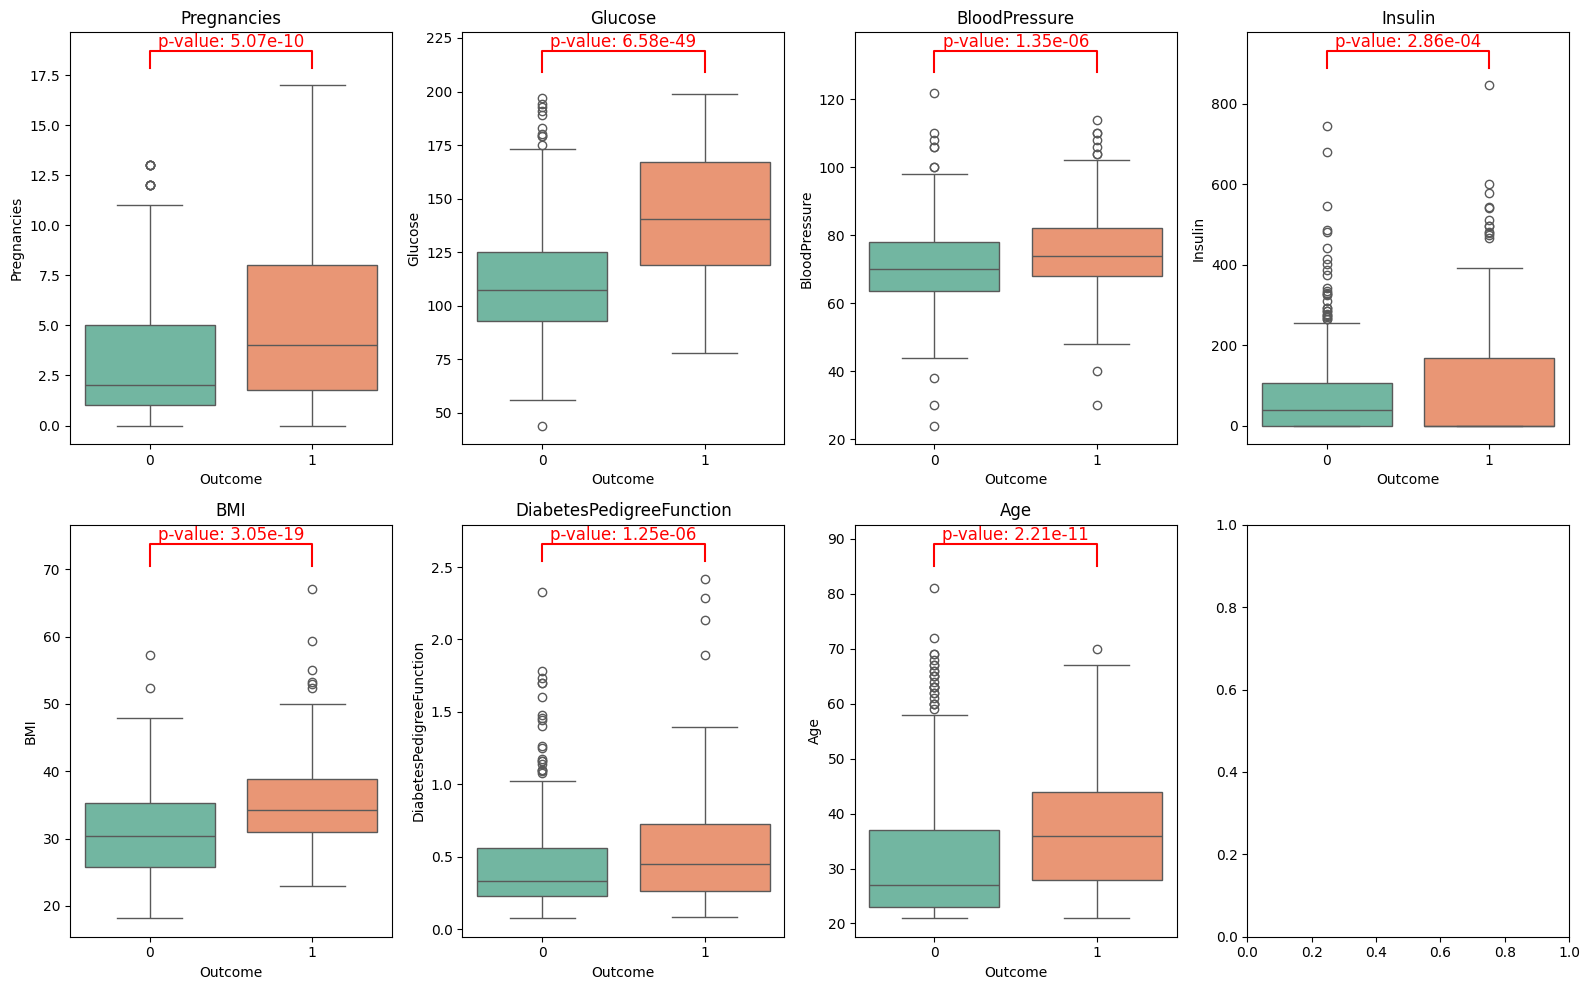

In [52]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Définir la palette de couleurs avec deux couleurs distinctes pour les deux niveaux de 'Outcome'
palette = sns.color_palette("Set2", 2)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x=data['Outcome'], y=feature, data=data, ax=axes[i], palette=palette, hue='Outcome', legend=False)
    t_stat, p_value = ttest_ind(data[data['Outcome'] == 0][feature], data[data['Outcome'] == 1][feature], nan_policy='omit')    
    max_value = data[feature].max()
    y, h, col = max_value + (max_value * 0.05), max_value * 0.05, 'blue'
    axes[i].plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=1.5, c='red')
    axes[i].text(0.5, y+h, f'p-value: {p_value:.2e}', ha='center', va='bottom', color='red', fontsize=12)
    axes[i].set_title(feature)


plt.tight_layout()
plt.show()

In [53]:
'''
TTEST : 

Résultats pour la colonne 'BloodPressure':
t-statistic: -1.8047023017353887
p-value: 0.07151390009776082

p > 0.05 > pas de corrélation démontrée d'apres pvalue
Cependant des études scientifiques montrent que 70% des personnes souffrant de diabete type 2
souffrent également d'hypertension donc on garde la colonne

'''

"\nTTEST : \n\nRésultats pour la colonne 'BloodPressure':\nt-statistic: -1.8047023017353887\np-value: 0.07151390009776082\n\np > 0.05 > pas de corrélation démontrée d'apres pvalue\nCependant des études scientifiques montrent que 70% des personnes souffrant de diabete type 2\nsouffrent également d'hypertension donc on garde la colonne\n\n"

In [54]:
'''
    Des etudes médicales ont demontrées que l'epaisseur de la peau n'etait pas corrolée au diabete, 
    de plus le test est difficile sur les diabétiques à cause de l'élasticité de la peau.
    On drop la colonne
    
'''

"\n    Des etudes médicales ont demontrées que l'epaisseur de la peau n'etait pas corrolée au diabete, \n    de plus le test est difficile sur les diabétiques à cause de l'élasticité de la peau.\n    On drop la colonne\n    \n"

In [55]:
data = data.drop(columns='SkinThickness')

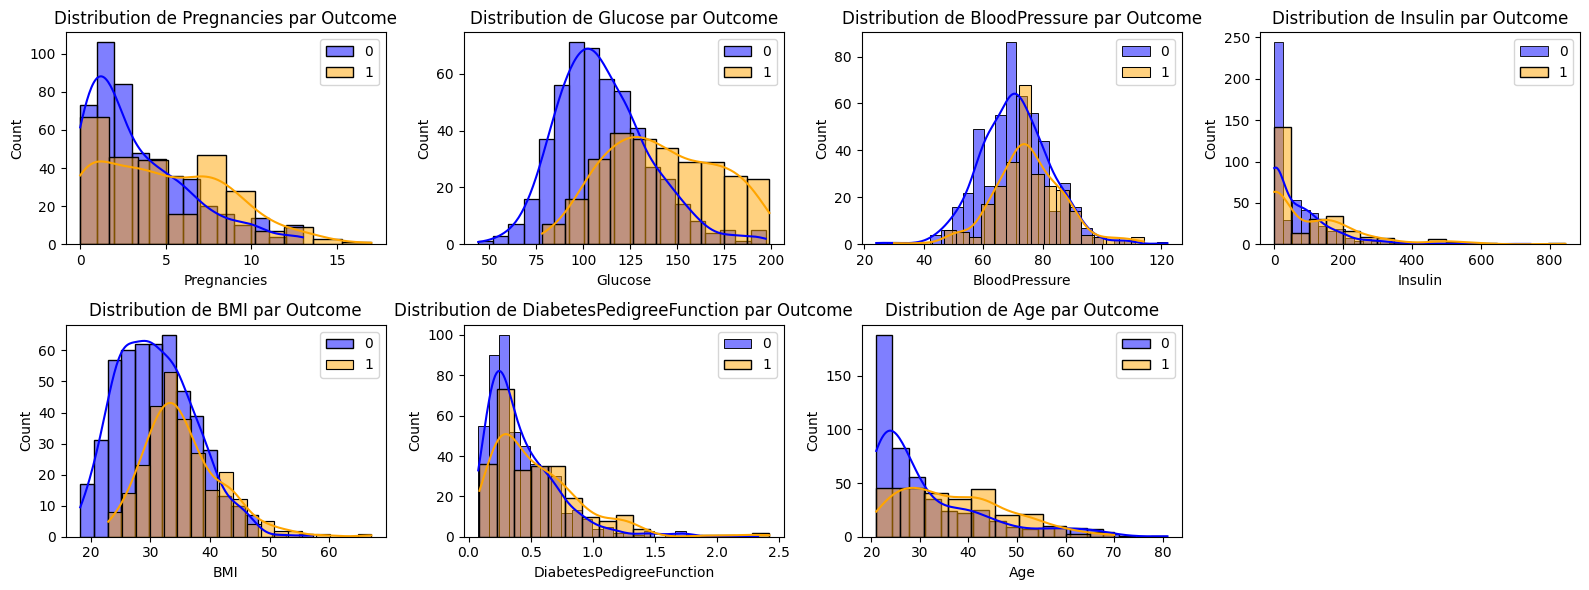

In [56]:
# Liste des caractéristiques à tracer
features = ["Pregnancies", "Glucose", "BloodPressure", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

# Créer des sous-graphiques
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
# Aplatir la liste des axes pour itérer plus facilement
axs = axs.flatten()

# Parcourir chaque caractéristique et tracer les distributions
for i, feature in enumerate(features):
    sns.histplot(data[data['Outcome'] == 0][feature], color='blue', kde=True, ax=axs[i], label='0')
    sns.histplot(data[data['Outcome'] == 1][feature], color='orange', kde=True, ax=axs[i], label='1')
    axs[i].set_title(f'Distribution de {feature} par Outcome')
    axs[i].legend()

# Masquer les sous-graphiques inutilisés
for j in range(i+1, len(axs)):
    axs[j].axis('off')

# Ajuster les espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

In [57]:
# Calculer la skewness pour chaque colonne pour Outcome = 1
skewness_outcome_1 = data[data['Outcome'] == 1].apply(lambda x: skew(x.dropna()))

# Calculer la skewness pour chaque colonne pour Outcome = 0
skewness_outcome_0 = data[data['Outcome'] == 0].apply(lambda x: skew(x.dropna()))

# Afficher les résultats
print("Skewness pour Outcome = 1 :")
print(skewness_outcome_1)

print("\nSkewness pour Outcome = 0 :")
print(skewness_outcome_0)

Skewness pour Outcome = 1 :
Pregnancies                 0.500925
Glucose                     0.091460
BloodPressure               0.099083
Insulin                     1.833495
BMI                         1.019101
DiabetesPedigreeFunction    1.712718
Age                         0.578385
Outcome                          NaN
dtype: float64

Skewness pour Outcome = 0 :
Pregnancies                 1.110760
Glucose                     0.655393
BloodPressure               0.172268
Insulin                     2.491239
BMI                         0.477131
DiabetesPedigreeFunction    2.000218
Age                         1.566891
Outcome                          NaN
dtype: float64


C:\Users\corre\AppData\Local\Temp\ipykernel_26512\1262868210.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness_outcome_1 = data[data['Outcome'] == 1].apply(lambda x: skew(x.dropna()))


### 2.2 - Traitement des doublons

In [58]:
data.duplicated().sum()

0

### 2.3 - Traitement des valeurs abérantes

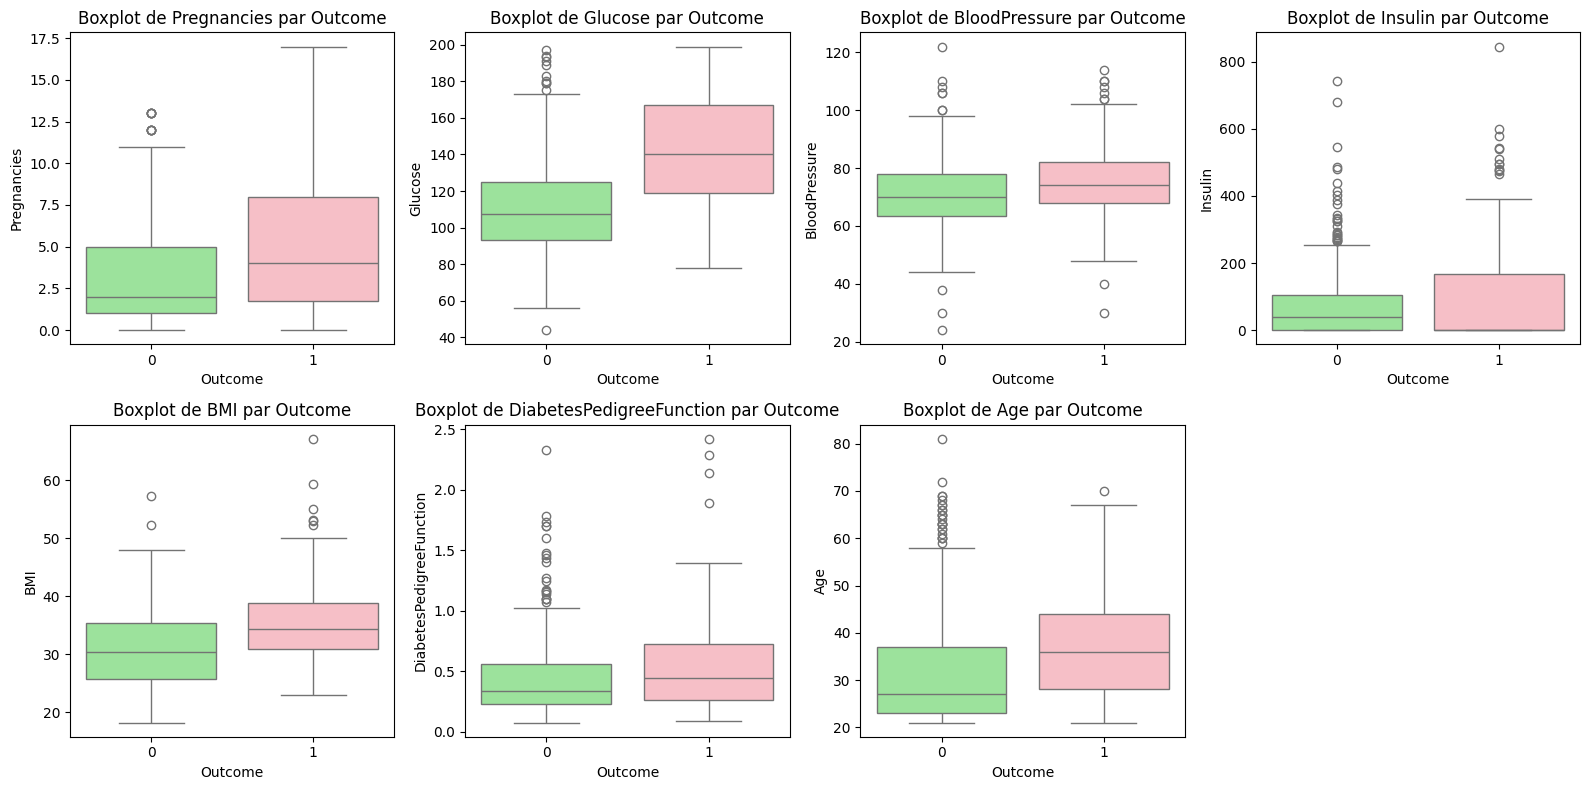

In [59]:
# Liste des caractéristiques à tracer
features = ["Pregnancies", "Glucose", "BloodPressure", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

# Créer des sous-graphiques
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

# Aplatir la liste des axes pour itérer plus facilement
axs = axs.flatten()

# Parcourir chaque caractéristique et tracer les boîtes à moustaches
for i, feature in enumerate(features):
    sns.boxplot(x='Outcome', y=feature, data=data, hue='Outcome', palette=['lightgreen', 'lightpink'], ax=axs[i], legend=False)
    axs[i].set_title(f'Boxplot de {feature} par Outcome')

# Masquer les sous-graphiques inutilisés
for j in range(i+1, len(axs)):
    axs[j].axis('off')

# Ajuster les espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

In [60]:
'''

Traiter les valeurs abérrantes de : 

    BMI car au dessus de 50/60, on est sur des valeurs extreme, 70 de BMI correspond a 306kg pour 1.75m
    Au dessus de 30 on parle deja d'obesité

    SkinThickNess valeur de 100 dans outcome = 1 impossible

    BloodPressure > valeurs extrement basse impossible, en dessous de 50 on est deja dans des situation med d'urgence
    donc pas possible pour un test

    les valeurs d'insuline peuvent s'expliquées mais ne vaut il pas mieux utiliser un standarScarler pour limiter les ecarts ?
    
'''

"\n\nTraiter les valeurs abérrantes de : \n\n    BMI car au dessus de 50/60, on est sur des valeurs extreme, 70 de BMI correspond a 306kg pour 1.75m\n    Au dessus de 30 on parle deja d'obesité\n\n    SkinThickNess valeur de 100 dans outcome = 1 impossible\n\n    BloodPressure > valeurs extrement basse impossible, en dessous de 50 on est deja dans des situation med d'urgence\n    donc pas possible pour un test\n\n    les valeurs d'insuline peuvent s'expliquées mais ne vaut il pas mieux utiliser un standarScarler pour limiter les ecarts ?\n    \n"

In [61]:
def remove_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Colonnes pour les outliers
colonnes_outlier_0 = ['Glucose', 'BMI', 'BloodPressure']
colonnes_outlier_1 = ['BMI', 'BloodPressure']

# Suppression des outliers
data_outlier_0 = remove_outliers(data_outcome_0, colonnes_outlier_0)
data_outlier_1 = remove_outliers(data_outcome_1, colonnes_outlier_1)

# Fusion des deux ensembles de données
data_clean_outlier_nan = pd.concat([data_outlier_0, data_outlier_1], ignore_index=True)

In [62]:
data_clean_outlier_nan.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,1,89,66,23,94,28.1,0.167,21,0
2,5,116,74,0,0,25.6,0.201,30,0
3,4,110,92,0,0,37.6,0.191,30,0
4,10,139,80,0,0,27.1,1.441,57,0


## 3 - Modélisation des données

## Test sur le DataFrame ou les outliers sont toujours présents. ##

In [63]:
# Initialisation des scalers
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'Normalizer': Normalizer(),
    'PowerTransformer': PowerTransformer()
}

In [64]:
# Définir les paramètres de chaque modèle
param_logistic = {
    'scaler': list(scalers.values()),  # Scalers à tester
    'classifier': [LogisticRegression(max_iter=1000, solver='saga')],  # 'saga' pour 'l1', 'l2
    'classifier__C': [10**-2, 10**-1, 10**0, 10**1, 10**2],  # Valeurs de régularisation
    'classifier__penalty': ['l1', 'l2'],  # Pénalités compatibles avec 'saga'
    'classifier__class_weight': [None, {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:25}]  # Poids pour déséquilibre
}


param_decision_tree = {
    'scaler': list(scalers.values()),
    'classifier': [DecisionTreeClassifier()],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': [None, {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:25}]
}

param_random_forest = {
    'scaler': list(scalers.values()),
    'classifier': [RandomForestClassifier()],
    'classifier__n_estimators': [10, 50, 100, 250],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': [None, {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:25}]
}

param_svc = {
    'scaler': list(scalers.values()),
    'classifier': [SVC()],
    'classifier__C': [10**-2, 10**-1, 10**0, 10**1, 10**2],
    'classifier__kernel': ['linear', 'rbf', 'poly'],
    'classifier__class_weight': [None, {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:25}]
}

param_knn = {
    'scaler': list(scalers.values()),
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': [2, 5, 10, 25, 50],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

param_gradient_boosting = {
    'scaler': list(scalers.values()),
    'classifier': [GradientBoostingClassifier()],
    'classifier__n_estimators': [10, 50, 100, 250],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

param_mlp = {
    'scaler': list(scalers.values()),
    'classifier': [MLPClassifier(max_iter=2000)],
    'classifier__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'classifier__activation': ['tanh', 'relu'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate': ['constant', 'adaptive']
}


In [65]:
# Initialisation des modèles de classification
models_params = {
    'LogisticRegression': param_logistic,
    'DecisionTreeClassifier': param_decision_tree,
    'RandomForestClassifier': param_random_forest,
    'SVC': param_svc,
    'KNeighborsClassifier': param_knn,
    'GradientBoostingClassifier': param_gradient_boosting,
    'MLPClassifier': param_mlp
}


In [68]:
# Séparation des caractéristiques et de la variable cible
X = data.drop(columns=['Outcome'])
y = data['Outcome']
# Equilibrage des echantillons target
ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(X, y)

X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

In [69]:
# Création du pipeline
pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('classifier', 'passthrough')
])


# attention 12 minutes environs pour test toutes les parametres

In [155]:
# Initialisation d'un dictionnaire pour stocker les résultats
results = {}

# Effectuer la recherche de grille pour chaque modèle
for model_name, params in models_params.items():
    print(f"Testing {model_name}...")
    grid = GridSearchCV(pipeline, params, cv=3, n_jobs=-1, scoring='roc_auc')
    grid.fit(X_res, y_res)
    results[model_name] = {
        'Best Score': grid.best_score_,
        'Best Params': grid.best_params_
    }

# Trouver le meilleur modèle
best_model_name = max(results, key=lambda k: results[k]['Best Score'])
best_score = results[best_model_name]['Best Score']
best_params = results[best_model_name]['Best Params']

print(f"\nBest Model: {best_model_name}")
print(f"Best Score: {best_score}")
print(f"Best Params: {best_params}")


Testing LogisticRegression...
Testing DecisionTreeClassifier...
Testing RandomForestClassifier...
Testing SVC...
Testing KNeighborsClassifier...
Testing GradientBoostingClassifier...
Testing MLPClassifier...

Best Model: KNeighborsClassifier
Best Score: 0.9373958793445549
Best Params: {'classifier': KNeighborsClassifier(metric='euclidean', n_neighbors=50, weights='distance'), 'classifier__metric': 'euclidean', 'classifier__n_neighbors': 50, 'classifier__weights': 'distance', 'scaler': StandardScaler()}


In [70]:
# Définir le pipeline avec StandardScaler et KNeighborsClassifier
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# Définir les paramètres à tester pour GridSearchCV
param_knn_standard_scaler = {
    'classifier__n_neighbors': [2, 5, 10, 25, 50],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialiser GridSearchCV avec le pipeline et les paramètres
grid_knn = GridSearchCV(pipeline_knn, param_knn_standard_scaler, cv=3, n_jobs=-1, scoring='roc_auc')

# Entraîner GridSearchCV sur les données équilibrées
grid_knn.fit(X_res, y_res)

# Afficher les meilleurs paramètres et le meilleur score
print("Best Params:", grid_knn.best_params_)
print("Best Score:", grid_knn.best_score_)

Best Params: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 50, 'classifier__weights': 'distance'}
Best Score: 0.9483098588912645


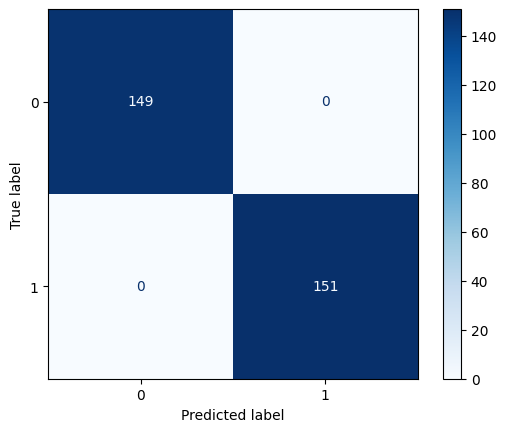

In [71]:
# Liste des colonnes pertinentes utilisées pour l'entraînement
used_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Créer un préprocesseur pour sélectionner uniquement les colonnes pertinentes
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), used_features)  # Applique StandardScaler aux colonnes pertinentes
    ],
    remainder='passthrough'  # Conserve les colonnes non spécifiées
)

# Définir le pipeline avec sélection de colonnes et KNeighborsClassifier
best_knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=50,
        weights='distance',
        metric='manhattan'
    ))
])

# Entraîner le modèle avec les données équilibrées
best_knn_pipeline.fit(X_res, y_res)

# Faire des prédictions avec les données de test
predictions = best_knn_pipeline.predict(X_test_res)

# Calculer et afficher la matrice de confusion
cm = confusion_matrix(y_test_res, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn_pipeline.classes_)
disp.plot(cmap='Blues')

In [72]:
# Sauvegarder le pipeline
joblib.dump(best_knn_pipeline, 'knn_diabete.plk')


['knn_diabete.plk']

# Données de test 

In [139]:
# Données des patients
data_1 = {
    "Pregnancies": [4, 0],
    "Glucose": [93, 132],
    "BloodPressure": [68, 39],
    "SkinThickness":  [25, 34],
    "Insulin": [93, 162],
    "BMI": [31.1, 41.1],
    "DiabetesPedigreeFunction": [0.183, 1.988],
    "Age": [26, 25]
}

# Création du DataFrame
df = pd.DataFrame(data_1)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4,93,68,25,93,31.1,0.183,26
1,0,132,39,34,162,41.1,1.988,25


In [167]:
# Faire des prédictions avec le modèle sur les nouvelles données
predictions = best_knn_pipeline.predict(df)

# Afficher les prédictions
print("Prédictions pour les nouvelles données : ", predictions)


Prédictions pour les nouvelles données :  [0 1]


## Test sans les outliers ##

In [173]:
data_clean_outlier_nan

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,1,89,66,23,94,28.1,0.167,21,0
2,5,116,74,0,0,25.6,0.201,30,0
3,4,110,92,0,0,37.6,0.191,30,0
4,10,139,80,0,0,27.1,1.441,57,0
...,...,...,...,...,...,...,...,...,...
693,1,128,88,39,110,36.5,1.057,37,1
694,0,123,72,0,0,36.3,0.258,52,1
695,6,190,92,0,0,35.5,0.278,66,1
696,9,170,74,31,0,44.0,0.403,43,1


In [176]:
# Séparation des caractéristiques et de la variable cible
X_no_outliers = data_clean_outlier_nan.drop(columns=['Outcome', 'SkinThickness'])
y_no_outliers = data_clean_outlier_nan['Outcome']

# Initialisation du RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Rééchantillonnage
X_res_no_outliers, y_res_no_outliers = ros.fit_resample(X_no_outliers, y_no_outliers)

# Diviser les données en ensembles d'entraînement et de test
X_train_no_outliers, X_test_no_outliers, y_train_no_outliers, y_test_no_outliers = train_test_split(
    X_res_no_outliers, 
    y_res_no_outliers, 
    test_size=0.25, 
    random_state=0, 
    stratify=y_res_no_outliers
)

# Afficher les tailles des ensembles de données pour vérifier
print(f"Ensemble d'entraînement : X_train: {X_train_no_outliers.shape}, y_train: {y_train_no_outliers.shape}")
print(f"Ensemble de test : X_test: {X_test_no_outliers.shape}, y_test: {y_test_no_outliers.shape}")


Ensemble d'entraînement : X_train: (684, 7), y_train: (684,)
Ensemble de test : X_test: (228, 7), y_test: (228,)


In [178]:
# Création du pipeline
pipeline_no_outliers = Pipeline([
    ('scaler', 'passthrough'),
    ('classifier', 'passthrough')
])


In [ ]:
# Exemple de pipeline de base
pipeline_no_outliers = Pipeline([
    ('scaler', 'passthrough'),
    ('classifier', 'passthrough')
])

# Initialisation d'un dictionnaire pour stocker les résultats
results_no_outliers = {}

# Effectuer la recherche de grille pour chaque modèle
for model_name, params in models_params.items():
    print(f"Testing {model_name}...")
    grid_no_outliers = GridSearchCV(pipeline_no_outliers, params, cv=3, n_jobs=-1, scoring='roc_auc')
    grid_no_outliers.fit(X_res_no_outliers, y_res_no_outliers)
    results_no_outliers[model_name] = {
        'Best Score': grid_no_outliers.best_score_,
        'Best Params': grid_no_outliers.best_params_
    }

# Trouver le meilleur modèle
best_model_name_no_outliers = max(results_no_outliers, key=lambda k: results_no_outliers[k]['Best Score'])
best_score_no_outliers = results_no_outliers[best_model_name_no_outliers]['Best Score']
best_params_no_outliers = results_no_outliers[best_model_name_no_outliers]['Best Params']

print(f"\nBest Model: {best_model_name_no_outliers}")
print(f"Best Score: {best_score_no_outliers}")
print(f"Best Params: {best_params_no_outliers}")
